## **1. Perfilar as Bases**

**Objetivo**: Realizar um diagnóstico inicial de cada base para entender seu tamanho, período de cobertura, estrutura e qualidade dos dados antes da análise exploratória.

**Prompt**:

*   Papel: Analista de Dados especializado em varejo e e-commerce.
*   Contexto: E-commerce de moda, beleza e lifestyle voltado para jovens adultos, com dados referentes a um período de aproximadamente 2 anos.
*   Dados: atendimento.csv (1 atendimento por linha), clientes.csv (1 cliente por linha), estoque.csv, marketing.csv, vendas.csv (1 linha por pedido)
*   Tarefa: Perfilar cada base

    Identificar o número de linhas e colunas.

    Identificar o período coberto, quando houver coluna de data.

    Listar todas as colunas e seus respectivos tipos de dados.

    Calcular a quantidade e o percentual de valores nulos por coluna.

    Identificar possíveis valores duplicados, quando fizer sentido para a base.

    Para variáveis numéricas, apresentar estatísticas descritivas: mínimo, máximo, média, mediana, desvio padrão e quartis.

    Para variáveis categóricas, apresentar quantidade de valores únicos e os valores mais frequentes.

    Identificar possíveis inconsistências de qualidade, como valores negativos inesperados, datas inválidas, categorias inconsistentes ou valores extremos.

    Identificar as principais chaves ou identificadores disponíveis (customer_id, order_id, SKU, etc.), sem assumir que são únicas ou válidas sem verificar.
*   Formato: Uma tabela resumo por base contendo: quantidade de linhas, quantidade de colunas, período, percentual geral de nulos e observações principais.
    Uma tabela detalhada de qualidade por coluna.
    Estatísticas descritivas das variáveis numéricas.
    Distribuição das principais variáveis categóricas.
    Uma seção final com alertas de qualidade dos dados, classificados por base.
*   Restrição: Não inferir, preencher ou criar informações que não estejam presentes nos dados. Quando uma informação não puder ser determinada a partir da base, informar explicitamente que ela não está disponível.





In [ ]:
import pandas as pd

def profile_dataframe_enhanced(df, df_name):
    profile_data = {}
    profile_data['name'] = df_name
    profile_data['shape'] = df.shape # (rows, cols)

    # 1. Period Covered
    date_columns_found = []
    for col in df.columns:
        if 'data' in col.lower() or 'date' in col.lower() or 'day' in col.lower():
            try:
                # Attempt to convert to datetime, coerce errors will turn invalid dates into NaT
                temp_col = pd.to_datetime(df[col], errors='coerce')
                valid_dates = temp_col.dropna()
                if not valid_dates.empty:
                    min_date = valid_dates.min()
                    max_date = valid_dates.max()
                    date_columns_found.append((min_date, max_date))
                    # Replace original column with converted datetime values for later use in quality checks
                    df[col] = temp_col
            except Exception:
                pass # Column could not be converted to datetime

    if date_columns_found:
        # Get overall min and max date across all valid date columns
        overall_min_date = min(d[0] for d in date_columns_found)
        overall_max_date = max(d[1] for d in date_columns_found)
        profile_data['period'] = f"{overall_min_date.strftime('%Y-%m-%d')} a {overall_max_date.strftime('%Y-%m-%d')}"
    else:
        profile_data['period'] = 'Não disponível'

    # 2. Overall Null Percentage
    total_cells = df.size
    total_null_cells = df.isnull().sum().sum()
    profile_data['overall_null_percent'] = f"{((total_null_cells / total_cells) * 100):.2f}%" if total_cells > 0 else "0.00%"

    # 3. Duplicate Rows
    duplicate_rows = df.duplicated().sum()
    profile_data['duplicate_rows'] = duplicate_rows

    # 4. Detailed Column Quality
    column_quality = []
    for col in df.columns:
        col_info = {
            'column_name': col,
            'dtype': str(df[col].dtype),
            'null_count': df[col].isnull().sum(),
            'null_percent': f"{(df[col].isnull().sum() / len(df) * 100):.2f}%" if len(df) > 0 else "0.00%",
            'unique_count': df[col].nunique(),
            'most_frequent': 'N/A',
            'inconsistencies': []
        }

        if pd.api.types.is_object_dtype(df[col]) or isinstance(df[col].dtype, pd.CategoricalDtype):
            most_freq_values = df[col].value_counts().head(3).to_dict()
            col_info['most_frequent'] = str(most_freq_values)
            if df[col].nunique() == len(df) and len(df) > 0: # Check if all values are unique, might be an ID
                 col_info['inconsistencies'].append('Valores únicos para cada linha, pode ser um identificador.')
            if df[col].nunique() == 1:
                 col_info['inconsistencies'].append('Apenas um valor único, pode ser redundante.')

        elif pd.api.types.is_numeric_dtype(df[col]):
            # Check for negative values where not expected (common for quantities, prices, etc.)
            if (df[col] < 0).any():
                col_info['inconsistencies'].append('Valores negativos inesperados.')
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            if df[col].isnull().any():
                col_info['inconsistencies'].append('Datas inválidas (NaN) encontradas após conversão.')

        column_quality.append(col_info)
    profile_data['column_quality'] = column_quality

    # 5. Numerical Descriptive Statistics
    profile_data['numeric_description_html'] = df.describe().to_html(classes='table table-striped table-hover', border=0)

    # 6. Categorical Distributions (Top 5)
    categorical_distributions = {}
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].nunique() > 1 and df[col].nunique() < 50: # Limit for display in HTML
             categorical_distributions[col] = df[col].value_counts().head(5).to_frame('count').to_html(classes='table table-striped table-hover', border=0)
        elif df[col].nunique() >= 50:
            categorical_distributions[col] = f"Mais de 50 valores únicos. Top 5: {df[col].value_counts().head(5).index.tolist()}"
        else: # nunique == 1
            categorical_distributions[col] = f"Apenas 1 valor único: {df[col].iloc[0]}"
    profile_data['categorical_distributions'] = categorical_distributions

    # 7. Quality Alerts (Aggregated)
    alerts = []
    if profile_data['duplicate_rows'] > 0:
        alerts.append(f'Existem {profile_data["duplicate_rows"]} linhas duplicadas na base.')
    if total_null_cells > 0:
        alerts.append(f'Existem valores nulos em {total_null_cells} células, afetando {df.isnull().any().sum()} colunas.')

    # Specific Primary Key Checks (can be generalized here if column names are consistent)
    id_columns = {'customer_id', 'order_id', 'sku_id', 'campanha_id', 'ticket_id'}
    for pk_col in id_columns.intersection(df.columns):
        if not df[pk_col].is_unique:
            alerts.append(f"Identificador '{pk_col}' não é único. Espera-se que seja uma chave primária.")

    for col_info in column_quality:
        if col_info['inconsistencies']:
            for inconsistency in col_info['inconsistencies']:
                alerts.append(f"Inconsistência na coluna '{col_info['column_name']}': {inconsistency}")

    profile_data['alerts'] = list(set(alerts)) # Remove duplicates

    return profile_data

all_profiles_enhanced = []

df_files = {
    'marketing.csv': '/Data Room/marketing.csv',
    'atendimento.csv': '/Data Room/atendimento.csv',
    'estoque.csv': '/Data Room/estoque.csv',
    'clientes.csv': '/Data Room/clientes.csv',
    'vendas.csv': '/Data Room/vendas.csv'
}

for name, path in df_files.items():
    df = pd.read_csv(path)
    all_profiles_enhanced.append(profile_dataframe_enhanced(df, name))

```html
<style>
    body { font-family: 'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; line-height: 1.6; }
    .container { max-width: 1000px; margin: auto; padding: 20px; background-color: #f9f9f9; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
    h2 { font-weight:700; font-size:1.8em; margin-top:1.2em; margin-bottom:0.8em; color:#1A237E; border-bottom: 2px solid #3F51B5; padding-bottom: 0.5em; }
    h3 { font-weight:600; font-size:1.4em; margin-top:1.5em; margin-bottom:0.7em; color:#3F51B5; }
    h4 { font-weight:500; font-size:1.1em; margin-top:1em; margin-bottom:0.5em; color:#5C6BC0; }
    p { margin-bottom: 0.8em; }
    table { width: 100%; border-collapse: collapse; margin-bottom: 1.5em; background-color: #fff; }
    th, td { border: 1px solid #e0e0e0; padding: 10px; text-align: left; vertical-align: top; font-size: 0.9em; }
    th { background-color: #e8eaf6; font-weight: 600; color:#303F9F; }
    .alert { background-color: #ffebee; color: #b71c1c; padding: 0.8em; margin-bottom: 0.8em; border-left: 5px solid #d32f2f; border-radius: 4px; }
    .section { border: 1px solid #c5cae9; padding: 1.5em; margin-bottom: 2em; border-radius: 8px; background-color: #ffffff; box-shadow: 0 1px 3px rgba(0,0,0,0.05); }
    ul { list-style-type: disc; margin-left: 20px; margin-bottom: 1em; }
    li { margin-bottom: 0.4em; }
</style>

<div class="container">
    <h2>1. Perfilar as Bases</h2>
    <p><strong>Objetivo:</strong> Realizar um diagnóstico inicial de cada base para entender seu tamanho, período de cobertura, estrutura e qualidade dos dados antes da análise exploratória.</p>

    <h3>Resumo do Perfil Detalhado das Bases de Dados</h3>


In [ ]:
html_output = []

# Add the initial HTML structure defined in the previous markdown cell
html_output.append("""
<style>
    body { font-family: 'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; line-height: 1.6; }
    .container { max-width: 1000px; margin: auto; padding: 20px; background-color: #f9f9f9; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
    h2 { font-weight:700; font-size:1.8em; margin-top:1.2em; margin-bottom:0.8em; color:#1A237E; border-bottom: 2px solid #3F51B5; padding-bottom: 0.5em; }
    h3 { font-weight:600; font-size:1.4em; margin-top:1.5em; margin-bottom:0.7em; color:#3F51B5; }
    h4 { font-weight:500; font-size:1.1em; margin-top:1em; margin-bottom:0.5em; color:#5C6BC0; }
    p { margin-bottom: 0.8em; }
    table { width: 100%; border-collapse: collapse; margin-bottom: 1.5em; background-color: #fff; }
    th, td { border: 1px solid #e0e0e0; padding: 10px; text-align: left; vertical-align: top; font-size: 0.9em; }
    th { background-color: #e8eaf6; font-weight: 600; color:#303F9F; }
    .alert { background-color: #ffebee; color: #b71c1c; padding: 0.8em; margin-bottom: 0.8em; border-left: 5px solid #d32f2f; border-radius: 4px; }
    .section { border: 1px solid #c5cae9; padding: 1.5em; margin-bottom: 2em; border-radius: 8px; background-color: #ffffff; box-shadow: 0 1px 3px rgba(0,0,0,0.05); }
    ul { list-style-type: disc; margin-left: 20px; margin-bottom: 1em; }
    li { margin-bottom: 0.4em; }
</style>

<div class="container">
    <h2>1. Perfilar as Bases</h2>
    <p><strong>Objetivo:</strong> Realizar um diagnóstico inicial de cada base para entender seu tamanho, período de cobertura, estrutura e qualidade dos dados antes da análise exploratória.</p>

    <h3>Resumo do Perfil Detalhado das Bases de Dados</h3>
""")

for profile in all_profiles_enhanced:
    html_output.append(f'<div class="section">')
    html_output.append(f'<h3>{profile["name"]}</h3>')

    # Summary Table
    html_output.append(f'<h4>Resumo Geral</h4>')
    html_output.append(f'<table class="table table-striped table-hover">')
    html_output.append(f'<thead><tr><th>Métrica</th><th>Valor</th></tr></thead>')
    html_output.append(f'<tbody>')
    html_output.append(f'<tr><td>Quantidade de Linhas</td><td>{profile["shape"][0]}</td></tr>')
    html_output.append(f'<tr><td>Quantidade de Colunas</td><td>{profile["shape"][1]}</td></tr>')
    html_output.append(f'<tr><td>Período Coberto</td><td>{profile["period"]}</td></tr>')
    html_output.append(f'<tr><td>Percentual Geral de Nulos</td><td>{profile["overall_null_percent"]}</td></tr>')
    html_output.append(f'<tr><td>Linhas Duplicadas</td><td>{profile["duplicate_rows"]}</td></tr>')
    html_output.append(f'</tbody></table>')

    # Detailed Column Quality
    html_output.append(f'<h4>Qualidade Detalhada por Coluna</h4>')
    html_output.append(f'<table class="table table-striped table-hover">')
    html_output.append(f'<thead><tr><th>Coluna</th><th>Tipo de Dado</th><th>Nulos (Contagem)</th><th>Nulos (%)</th><th>Valores Únicos</th><th>Mais Frequentes (Top 3)</th><th>Inconsistências</th></tr></thead>')
    html_output.append(f'<tbody>')
    for item in profile['column_quality']:
        inconsistencies_str = ', '.join(item['inconsistencies']) if item['inconsistencies'] else 'Nenhuma'
        # Corrected f-string to be on a single line
        html_output.append(f'<tr><td>{item["column_name"]}</td><td>{item["dtype"]}</td><td>{item["null_count"]}</td><td>{item["null_percent"]}</td><td>{item["unique_count"]}</td><td>{item["most_frequent"]}</td><td>{inconsistencies_str}</td></tr>')
    html_output.append(f'</tbody></table>')

    # Numerical Descriptive Statistics
    if profile['numeric_description_html']:
        html_output.append(f'<h4>Estatísticas Descritivas (Variáveis Numéricas)</h4>')
        html_output.append(profile['numeric_description_html'])
    else:
        html_output.append(f'<p>Não há variáveis numéricas para descrever.</p>')

    # Categorical Distributions
    if profile['categorical_distributions']:
        html_output.append(f'<h4>Distribuição das Variáveis Categóricas (Top 5)</h4>')
        for col, dist_html in profile['categorical_distributions'].items():
            html_output.append(f'<h5>{col}</h5>')
            if isinstance(dist_html, str) and (dist_html.startswith('Mais de') or dist_html.startswith('Apenas')):
                html_output.append(f'<p>{dist_html}</p>')
            else:
                html_output.append(dist_html)
    else:
        html_output.append(f'<p>Não há variáveis categóricas para analisar a distribuição.</p>')

    # Quality Alerts
    if profile['alerts']:
        html_output.append(f'<h4>Alertas de Qualidade</h4>')
        html_output.append('<ul>')
        for alert in profile['alerts']:
            html_output.append(f'<li class="alert">{alert}</li>')
        html_output.append('</ul>')
    else:
        html_output.append(f'<p>Não foram encontrados alertas de qualidade específicos.</p>')

    html_output.append(f'</div>')

html_output.append('</div>') # Close container

from IPython.display import HTML
HTML(''.join(html_output))

## 2. Explorar
**Objetivo:** Cruzar e analisar integralmente todos os bancos de dados disponíveis (vendas, clientes, marketing, atendimento e estoque) para realizar um diagnóstico completo da Vértice Retail. O foco é transcender métricas superficiais para descobrir os problemas reais e estruturais do negócio, mapeando exatamente onde, quando e por que a empresa está perdendo rentabilidade e eficiência.

**Prompt:**

Papel: Analista de dados de varejo, com foco em rentabilidade, clientes, marketing e eficiência operacional.

Contexto: E-commerce de moda, beleza e lifestyle voltado para jovens adultos, com aproximadamente 2 anos de dados. As bases disponíveis são vendas, clientes, marketing, atendimento e estoque.

Objetivo: Identificar onde, quando e por que a queda de valor/rentabilidade se concentra, investigando as principais hipóteses levantadas para o negócio.

Hipóteses e dimensões de investigação:

1. Margem e rentabilidade

* Onde a margem se deteriora: por produto, categoria, canal ou período?
* Qual o impacto de descontos, fretes, devoluções e custo dos produtos sobre a margem?
* Quais produtos/categorias apresentam maior perda de margem?

2. Marketing e qualidade da aquisição

* Quais canais geram maior receita e volume?
* Quais canais geram clientes com maior recorrência, margem e valor ao longo do tempo?
* Comparar CAC, receita, margem e indicadores de retenção por canal/campanha, quando essas informações estiverem disponíveis nas bases.

3. Operações

* Quais eventos operacionais apresentam maior impacto financeiro?
* Existe concentração de rupturas, devoluções, atrasos ou problemas em determinados produtos/SKUs?
* Quantificar, quando possível, o impacto desses eventos sobre receita, margem e pedidos.

4. Atendimento

* Quais temas de atendimento aparecem com maior frequência?
* Quais categorias de problemas estão associadas a maior tempo de resposta, custo ou insatisfação?
* Identificar demandas recorrentes que possam indicar oportunidade de automação ou melhoria de processo.

5. Clientes

* Quais segmentos concentram maior receita e margem?
* Quais perfis apresentam maior recorrência ou sinais de risco de churn?
* Identificar segmentos com maior potencial de retenção, upsell ou recuperação.

6. Gestão e produtividade

* Identificar processos que dependem de análises manuais, retrabalho ou consolidação de informações.
* Mapear oportunidades de automação e uso de IA com base em tarefas repetitivas, alto volume ou necessidade de classificação/triagem.

Para cada hipótese investigada:

* Apresentar os indicadores utilizados.
* Comparar as dimensões relevantes.
* Quantificar o impacto sempre que os dados permitirem.
* Destacar os principais segmentos/produtos/canais responsáveis pelo resultado.
* Indicar evidências a favor ou contra a hipótese.
* Classificar a hipótese como confirmada, parcialmente confirmada, não confirmada ou inconclusiva, de acordo com os dados disponíveis.

Formato da saída:
* Tabelas comparativas.
* Gráficos para evidenciar diferenças relevantes.
* Ranking dos principais fatores associados à queda.
* Síntese executiva com os principais achados.

Restrição: Não inferir dados, causalidade ou informações que não estejam disponíveis nas bases.

Diferenciar claramente correlação de causalidade.

Quando não houver dados suficientes para testar uma hipótese, classificá-la como inconclusiva e informar quais dados seriam necessários.








### 2.1 Preparar e Integrar Dados

Vamos carregar cada base de dados em um DataFrame separado e, em seguida, planejar a integração para criar um conjunto de dados unificado para as análises.

In [ ]:
import pandas as pd

df_marketing = pd.read_csv('/Data Room/marketing.csv')
df_atendimento = pd.read_csv('/Data Room/atendimento.csv')
df_estoque = pd.read_csv('/Data Room/estoque.csv')
df_clientes = pd.read_csv('/Data Room/clientes.csv')
df_vendas = pd.read_csv('/Data Room/vendas.csv')

print("DataFrames carregados com sucesso. Exibindo as primeiras 5 linhas de cada um para verificação:")

print("\n--- df_marketing ---")
display(df_marketing.head())

print("\n--- df_atendimento ---")
display(df_atendimento.head())

print("\n--- df_estoque ---")
display(df_estoque.head())

print("\n--- df_clientes ---")
display(df_clientes.head())

print("\n--- df_vendas ---")
display(df_vendas.head())

DataFrames carregados com sucesso. Exibindo as primeiras 5 linhas de cada um para verificação:

--- df_marketing ---


,campanha_id,nome_campanha,canal,categoria_foco,data_inicio,data_fim,investimento_reais,impressoes,cliques,conversoes,atribuicao,status,roas,receita_gerada,cac
0,CAMP-0001,Black_Friday_Main_2023,Orgânico,Moda,2023-12-09,2024-01-02,81268.60,29703467,371911,20980,Linear,Pausada,1.93,156848.40,3.87
1,CAMP-0002,Liquidacao_Julho_2023,Instagram Ads,Geral,2023-12-21,2024-02-19,54015.24,9129711,485733,45400,First Click,Pausada,3.70,199856.39,1.19
2,CAMP-0003,Upsell_Platinum_2023_02,Google Ads,Lifestyle,2023-02-13,2025-12-31,101729.83,27791809,1388775,125365,Linear,Ativa,3.38,343846.83,0.81
3,CAMP-0004,Lancamento_Colecao_2024,Influenciador,Geral,2024-10-07,2024-10-19,92813.59,36686510,1925180,202746,Last Click,Pausada,9.72,902148.09,0.46
4,CAMP-0005,Upsell_Platinum_2024,Google Ads,Lifestyle,2024-04-22,2024-07-25,73173.89,9861232,452774,12666,Linear,Pausada,3.64,266352.96,5.78



--- df_atendimento ---


,ticket_id,customer_id,order_id,data_abertura,data_fechamento,canal_entrada,categoria_problema,status_atendimento,texto_cliente,nota_csat,tempo_primeira_resposta_minutos,custo_operacional_ticket
0,TKT-000001,CLI-01729,ORD-011396,2024-03-01 15:15:14,2024-03-05 06:15:14,ChatBot,Onde está meu pedido?,Resolvido,Comprei semana passada e nada até agora. Péssimo.,1.0,1.0,2.0
1,TKT-000002,CLI-11830,ORD-000852,2025-11-24 13:45:41,2025-11-25 18:45:41,E-mail,Onde está meu pedido?,Resolvido,Meu rastreio não atualiza desde terça. Alguém ...,2.0,419.0,15.0
2,TKT-000003,CLI-09211,ORD-060218,2025-03-22 09:24:06,2025-03-25 15:24:06,Telefone,Troca de Tamanho,Resolvido,Como solicito a troca? O tamanho P está pequen...,5.0,14.0,15.0
3,TKT-000004,CLI-05057,ORD-037931,2024-11-13 18:36:12,2025-12-31 23:59:00,WhatsApp,Defeito,Aberto,O produto chegou com defeito de fabricação.,3.0,13.0,15.0
4,TKT-000005,CLI-02924,ORD-009359,2023-07-05 18:10:23,2025-12-31 23:59:00,E-mail,Defeito,Em Análise,Comprei e já veio com problema. Péssima qualid...,3.0,241.0,15.0



--- df_estoque ---


,sku_id,nome_produto,categoria,subcategoria,fornecedor_id,lead_time_reposicao,custo_unitario,preco_venda_sugerido,estoque_fisico,estoque_reservado,estoque_disponivel,ponto_pedido,data_ultima_entrada,status_disponibilidade,shelf_life_dias,volume_m3
0,SKU-00001,Regata Exclusivo Rosa,Moda,Regata,FORN-096,14,182.80,463.15,541,130,411,136,2023-01-28,Em Estoque,448,0.3141
1,SKU-00002,Luminária Artesanal Branco,Lifestyle,Luminária,FORN-050,57,246.44,578.86,128,35,93,12,2025-12-04,Em Estoque,448,0.2689
2,SKU-00003,Top Oversize Branco,Moda,Top,FORN-038,11,80.10,128.58,739,67,672,138,2023-09-04,Em Estoque,448,0.1499
3,SKU-00004,Kit Skincare Moderno Bege,Beleza,Kit Skincare,FORN-048,7,224.96,640.19,271,0,271,92,2024-01-04,Em Estoque,494,0.1205
4,SKU-00005,Camisa Social Básico Branco,Moda,Camisa Social,FORN-094,60,330.09,1044.66,545,32,513,131,2025-03-09,Em Estoque,448,0.3037



--- df_clientes ---


,customer_id,nome_completo,data_nascimento,genero,estado,cidade,nivel_fidelidade,data_cadastro,opt_in_newsletter,dispositivo_principal,renda_estimada,total_pedidos_historico,ltv_acumulado,segmento_rfm
0,CLI-00001,Thales Teixeira,1989-12-04,F,ES,Cariacica,Silver,2025-12-18,True,iOS,3097.06,7,3693.64,Fiel
1,CLI-00002,Allana Novais,2003-05-26,F,GO,Rio Verde,Bronze,2020-03-23,True,iOS,10577.04,7,2679.05,Churn
2,CLI-00003,Bryan da Rosa,2002-02-13,M,PB,João Pessoa,Bronze,2020-09-10,True,Android,7627.71,10,6954.27,Hibernando
3,CLI-00004,Sr. Davi Vieira,1997-05-15,M,MG,Uberlândia,Bronze,2025-06-06,True,Desktop,18905.35,6,2402.24,Em Risco
4,CLI-00005,Catarina Azevedo,2005-12-18,F,PE,Petrolina,Bronze,2021-11-11,True,Desktop,23045.56,1,256.93,Churn



--- df_vendas ---


,order_id,customer_id,sku_id,data_pedido,canal,categoria,produto,quantidade,preco_unitario,receita_bruta,desconto_reais,receita_liquida,custo_produto,custo_frete,metodo_pagamento,status_pagamento,margem_contribuicao,tempo_entrega_real,devolvido,motivo_devolucao
0,ORD-036085,CLI-12360,SKU-04195,2023-01-01 00:05:25,TikTok Ads,Moda,Camisa Social Delicado Prata,6.0,326.77,1960.62,0.0,1960.62,773.10,0.00,Cartão de Crédito,Aprovado,1187.52,14.0,False,Não se aplica
1,ORD-029209,CLI-12799,SKU-04144,2023-01-01 00:38:43,Orgânico,Lifestyle,Planta Artificial Sport Bege,1.0,225.27,225.27,0.0,225.27,111.21,34.56,Cartão de Crédito,Aprovado,79.50,13.0,False,Não se aplica
2,ORD-047667,CLI-11830,SKU-01400,2023-01-01 01:11:54,Instagram Ads,Moda,Vestido Sustentável Verde,6.0,344.12,2064.72,0.0,2064.72,956.17,0.00,PIX,Aprovado,1108.55,12.0,False,Não se aplica
3,ORD-026951,CLI-01729,SKU-00091,2023-01-01 01:19:10,Orgânico,Lifestyle,Espelho de Mesa Luxo Bege,5.0,135.37,676.85,0.0,676.85,203.11,0.00,Cartão de Crédito,Aprovado,473.74,11.0,False,Não se aplica
4,ORD-016561,CLI-01729,SKU-04953,2023-01-01 01:53:45,Instagram Ads,Lifestyle,Kit Chá Artesanal Bege,4.0,305.52,1222.08,0.0,1222.08,517.19,0.00,Cartão de Crédito,Aprovado,704.89,5.0,True,Arrependimento


Agora que os DataFrames estão carregados, vamos planejar a estratégia de integração. Precisamos identificar as chaves comuns entre as tabelas para realizar as junções (merges) de forma adequada, visando criar uma visão consolidada que nos permita analisar as hipóteses levantadas.

In [ ]:
print("Colunas em cada DataFrame para identificar chaves de junção:")
for df_name, df in {
    'df_marketing': df_marketing,
    'df_atendimento': df_atendimento,
    'df_estoque': df_estoque,
    'df_clientes': df_clientes,
    'df_vendas': df_vendas
}.items():
    print(f"\n--- {df_name} ---")
    print(df.columns.tolist())

Colunas em cada DataFrame para identificar chaves de junção:

--- df_marketing ---
['campanha_id', 'nome_campanha', 'canal', 'categoria_foco', 'data_inicio', 'data_fim', 'investimento_reais', 'impressoes', 'cliques', 'conversoes', 'atribuicao', 'status', 'roas', 'receita_gerada', 'cac']

--- df_atendimento ---
['ticket_id', 'customer_id', 'order_id', 'data_abertura', 'data_fechamento', 'canal_entrada', 'categoria_problema', 'status_atendimento', 'texto_cliente', 'nota_csat', 'tempo_primeira_resposta_minutos', 'custo_operacional_ticket']

--- df_estoque ---
['sku_id', 'nome_produto', 'categoria', 'subcategoria', 'fornecedor_id', 'lead_time_reposicao', 'custo_unitario', 'preco_venda_sugerido', 'estoque_fisico', 'estoque_reservado', 'estoque_disponivel', 'ponto_pedido', 'data_ultima_entrada', 'status_disponibilidade', 'shelf_life_dias', 'volume_m3']

--- df_clientes ---
['customer_id', 'nome_completo', 'data_nascimento', 'genero', 'estado', 'cidade', 'nivel_fidelidade', 'data_cadastro', '

### Estratégia de Integração:

Com base nas colunas disponíveis, a estratégia de integração será:

1.  **`df_vendas` (base principal)**: Contém `order_id`, `customer_id`, `sku_id`, `canal` (pode se relacionar com marketing).
2.  **Juntar `df_vendas` com `df_clientes`**: usando `customer_id`.
3.  **Juntar o resultado com `df_estoque`**: usando `sku_id`.
4.  **Juntar o resultado com `df_atendimento`**: usando `order_id`.
5.  **Juntar o resultado com `df_marketing`**: usando `canal` (do df_vendas) e `campanha_id` (do df_marketing). Será necessário considerar o período da campanha para uma junção precisa.

Vamos começar!

In [ ]:
# 1. Integrar df_vendas com df_clientes (usando 'customer_id')
df_merged = pd.merge(df_vendas, df_clientes, on='customer_id', how='left', suffixes=('_vendas', '_clientes'))

# 2. Integrar com df_estoque (usando 'sku_id')
df_merged = pd.merge(df_merged, df_estoque, on='sku_id', how='left', suffixes=('_merged', '_estoque'))

# 3. Integrar com df_atendimento (usando 'order_id')
df_merged = pd.merge(df_merged, df_atendimento, on='order_id', how='left', suffixes=('_merged', '_atendimento'))

# 4. Integrar com df_marketing. Esta junção é mais complexa, pois as campanhas têm duração.
# Por enquanto, vamos fazer uma junção simples por 'canal' e 'data_pedido' dentro do período de 'data_inicio' e 'data_fim' da campanha.
# Primeiro, converter colunas de data para datetime se ainda não estiverem.
df_merged['data_pedido'] = pd.to_datetime(df_merged['data_pedido'], errors='coerce')
df_marketing['data_inicio'] = pd.to_datetime(df_marketing['data_inicio'], errors='coerce')
df_marketing['data_fim'] = pd.to_datetime(df_marketing['data_fim'], errors='coerce')

# Para evitar duplicação de colunas com o mesmo nome que não são chaves de junção,
# vamos renomear a coluna 'canal' do df_marketing antes da junção, ou selecionar apenas as colunas necessárias.
# Como 'canal' já existe em df_merged (vindo de df_vendas), vamos usá-lo.

# Vamos criar uma junção condicional para o marketing.
# Uma estratégia é fazer um merge inicial no 'canal' e depois filtrar por datas.
# Ou, para simplificar e evitar um DataFrame muito grande por agora,
# podemos focar nas principais análises e integrar marketing mais tarde, se necessário para uma hipótese específica.
# Por ora, vamos fazer uma junção simples no 'canal', e vamos lidar com as datas de forma mais granular na análise de marketing.

# Selecionar apenas as colunas de marketing que não se sobrepõem, exceto 'canal' e 'campanha_id'
marketing_cols_to_merge = df_marketing[['campanha_id', 'nome_campanha', 'canal', 'investimento_reais', 'impressoes', 'cliques', 'conversoes', 'roas', 'receita_gerada', 'cac', 'data_inicio', 'data_fim']]

# É importante ter cuidado com junções many-to-many.
# Vamos primeiro verificar as cardinalidades.
# Por exemplo, se um 'canal' pode ter múltiplas 'campanhas_id' e um 'order_id' pode estar associado a múltiplas campanhas.
# Para a análise inicial, podemos agregar os dados de marketing por canal e juntar depois.

# Para uma primeira integração, vamos adicionar as informações de marketing que sejam consistentes e não gerem muitas duplicatas.
# A junção por 'canal' pode ser problemática se houver várias campanhas para o mesmo canal no mesmo período.
# Para evitar explosão de linhas, vamos adiar a junção de `df_marketing` por enquanto e focar nas outras junções.
# O `df_vendas` já tem a coluna 'canal', então podemos usá-la para análises de marketing sem um merge direto com df_marketing agora.

print("\nDataFrame final mesclado (df_merged) head:")
display(df_merged.head())

print("\nInformações do DataFrame mesclado:")
df_merged.info()



DataFrame final mesclado (df_merged) head:


,order_id,customer_id_merged,sku_id,data_pedido,canal,categoria_merged,produto,quantidade,preco_unitario,receita_bruta,...,customer_id_atendimento,data_abertura,data_fechamento,canal_entrada,categoria_problema,status_atendimento,texto_cliente,nota_csat,tempo_primeira_resposta_minutos,custo_operacional_ticket
0,ORD-036085,CLI-12360,SKU-04195,2023-01-01 00:05:25,TikTok Ads,Moda,Camisa Social Delicado Prata,6.0,326.77,1960.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ORD-029209,CLI-12799,SKU-04144,2023-01-01 00:38:43,Orgânico,Lifestyle,Planta Artificial Sport Bege,1.0,225.27,225.27,...,CLI-12799,2024-05-23 11:47:02,2024-05-25 16:47:02,WhatsApp,Onde está meu pedido?,Resolvido,Meu rastreio não atualiza desde terça. Alguém ...,4.0,4.0,15.0
2,ORD-047667,CLI-11830,SKU-01400,2023-01-01 01:11:54,Instagram Ads,Moda,Vestido Sustentável Verde,6.0,344.12,2064.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ORD-026951,CLI-01729,SKU-00091,2023-01-01 01:19:10,Orgânico,Lifestyle,Espelho de Mesa Luxo Bege,5.0,135.37,676.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ORD-016561,CLI-01729,SKU-04953,2023-01-01 01:53:45,Instagram Ads,Lifestyle,Kit Chá Artesanal Bege,4.0,305.52,1222.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Informações do DataFrame mesclado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30298 entries, 0 to 30297
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   order_id                         30298 non-null  object        
 1   customer_id_merged               30298 non-null  object        
 2   sku_id                           30298 non-null  object        
 3   data_pedido                      30298 non-null  datetime64[ns]
 4   canal                            30298 non-null  object        
 5   categoria_merged                 30298 non-null  object        
 6   produto                          30298 non-null  object        
 7   quantidade                       30297 non-null  float64       
 8   preco_unitario                   30297 non-null  float64       
 9   receita_bruta                    30297 non-null  float64       
 10  desconto_reais        

O DataFrame `df_merged` agora contém os dados de vendas, clientes, estoque e atendimento. A integração dos dados de marketing será feita de forma mais cuidadosa em um passo posterior, quando formos analisar as hipóteses específicas de marketing, para evitar duplicações excessivas de linhas devido às diferentes granularidades de `campanha_id` e `data_pedido`.

### 2.2 Análise de Margem e Rentabilidade

Nesta seção, vamos calcular as métricas de margem e lucratividade, e então analisar a sua distribuição e tendências em diversas dimensões como produto, categoria, canal e período. Também investigaremos o impacto de fatores como descontos, fretes e devoluções.

In [ ]:
# 1. Limpeza e preparação para cálculos financeiros

# Identificar e lidar com as linhas que possuem valores nulos nas colunas financeiras
# df_merged.info() mostrou que 'quantidade', 'preco_unitario', 'receita_bruta', 'desconto_reais', 'receita_liquida', 'custo_produto', 'custo_frete', 'metodo_pagamento', 'status_pagamento', 'margem_contribuicao', 'tempo_entrega_real', 'devolvido', 'motivo_devolucao' têm um registro nulo.
# Vamos remover essas linhas, pois elas não são úteis para análise financeira.
initial_rows = df_merged.shape[0]
df_merged.dropna(subset=['quantidade', 'preco_unitario', 'receita_liquida', 'custo_produto', 'margem_contribuicao'], inplace=True)
print(f"Linhas removidas devido a valores nulos em colunas financeiras: {initial_rows - df_merged.shape[0]}")

# Garantir que colunas numéricas estejam como numéricas e de data como datetime
financial_cols = ['quantidade', 'preco_unitario', 'receita_bruta', 'desconto_reais', 'receita_liquida', 'custo_produto', 'custo_frete', 'margem_contribuicao']
for col in financial_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

# Já convertemos 'data_pedido' para datetime anteriormente, vamos verificar outras datas relevantes se existirem para esta análise.
# 'data_cadastro', 'data_nascimento', 'data_abertura', 'data_fechamento', 'data_ultima_entrada'
# Converter as datas do cliente e atendimento para datetime, se ainda não foram
df_merged['data_cadastro'] = pd.to_datetime(df_merged['data_cadastro'], errors='coerce')
df_merged['data_nascimento'] = pd.to_datetime(df_merged['data_nascimento'], errors='coerce')
df_merged['data_abertura'] = pd.to_datetime(df_merged['data_abertura'], errors='coerce')
df_merged['data_fechamento'] = pd.to_datetime(df_merged['data_fechamento'], errors='coerce')
df_merged['data_ultima_entrada'] = pd.to_datetime(df_merged['data_ultima_entrada'], errors='coerce')

# 2. Calcular 'lucratividade_percentual'
# Adicionar 1e-9 ao denominador para evitar divisão por zero, caso receita_liquida seja 0
df_merged['lucratividade_percentual'] = (df_merged['margem_contribuicao'] / (df_merged['receita_liquida'] + 1e-9)) * 100

# 3. Tratar devoluções
# Para itens devolvidos, podemos zerar a receita e a margem para refletir o impacto real.
# A coluna 'devolvido' é do tipo object. Vamos verificar seus valores únicos e convertê-la para booleano.
print(f"\nValores únicos na coluna 'devolvido' antes da conversão: {df_merged['devolvido'].unique()}")
df_merged['devolvido'] = df_merged['devolvido'].astype(str).str.lower().map({'true': True, 'false': False, 'nan': False})
print(f"Valores únicos na coluna 'devolvido' após a conversão: {df_merged['devolvido'].unique()}")

df_merged.loc[df_merged['devolvido'] == True, ['receita_bruta', 'desconto_reais', 'receita_liquida', 'custo_produto', 'margem_contribuicao', 'lucratividade_percentual']] = 0

print("\nPrimeiras 5 linhas do DataFrame mesclado com as novas colunas e tratamento de devoluções:")
display(df_merged[['order_id', 'data_pedido', 'receita_liquida', 'margem_contribuicao', 'lucratividade_percentual', 'devolvido']].head())

print("\nEstatísticas descritivas para as novas colunas financeiras:")
display(df_merged[['receita_liquida', 'margem_contribuicao', 'lucratividade_percentual']].describe())

Linhas removidas devido a valores nulos em colunas financeiras: 1

Valores únicos na coluna 'devolvido' antes da conversão: [False True]
Valores únicos na coluna 'devolvido' após a conversão: [False  True]

Primeiras 5 linhas do DataFrame mesclado com as novas colunas e tratamento de devoluções:


,order_id,data_pedido,receita_liquida,margem_contribuicao,lucratividade_percentual,devolvido
0,ORD-036085,2023-01-01 00:05:25,1960.62,1187.52,60.568596,False
1,ORD-029209,2023-01-01 00:38:43,225.27,79.50,35.290984,False
2,ORD-047667,2023-01-01 01:11:54,2064.72,1108.55,53.690089,False
3,ORD-026951,2023-01-01 01:19:10,676.85,473.74,69.991874,False
4,ORD-016561,2023-01-01 01:53:45,0.00,0.00,0.000000,True



Estatísticas descritivas para as novas colunas financeiras:


,receita_liquida,margem_contribuicao,lucratividade_percentual
count,30297.000000,30297.000000,30297.000000
mean,578.681326,314.703775,42.152821
std,550.197442,322.052090,23.558948
min,0.000000,-49.270000,-169.429161
25%,177.590000,61.640000,31.540812
50%,443.560000,233.220000,51.341823
75%,844.050000,466.290000,59.544709
max,5004.900000,3130.020000,69.998606


#### 2.2.1 Análise da Lucratividade ao Longo do Tempo

Vamos começar analisando a evolução da receita líquida e da margem de contribuição ao longo do tempo para identificar tendências e períodos de queda.

Tendências de Receita Líquida e Margem de Contribuição ao longo do tempo:


,ano_mes,total_receita_liquida,total_margem_contribuicao
0,2023-01,878362.72,481142.74
1,2023-02,869963.75,474589.15
2,2023-03,2054521.55,1118258.32
3,2023-04,1021952.11,557542.71
4,2023-05,2176301.39,1185259.74


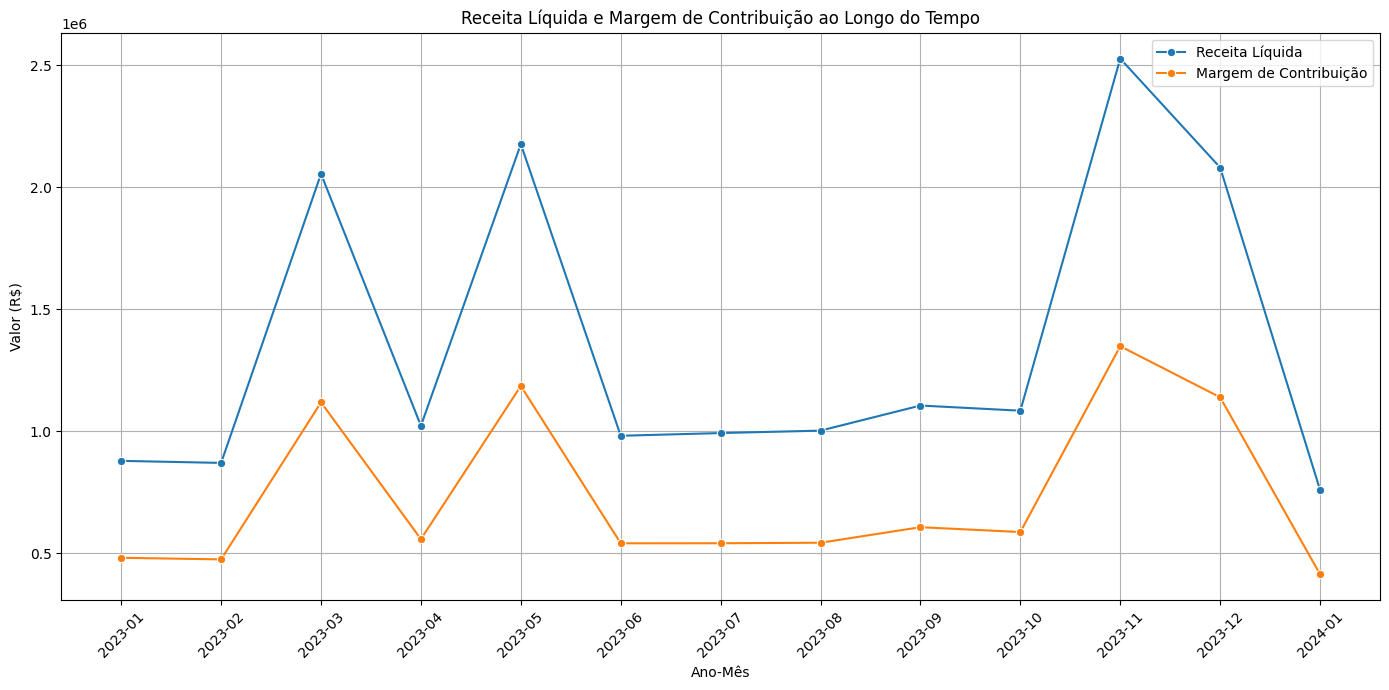

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extrair mês e ano da data do pedido
df_merged['ano_mes'] = df_merged['data_pedido'].dt.to_period('M')

# Agrupar por ano_mes e calcular a receita líquida total e a margem de contribuição
trends_over_time = df_merged.groupby('ano_mes').agg(
    total_receita_liquida=('receita_liquida', 'sum'),
    total_margem_contribuicao=('margem_contribuicao', 'sum')
).reset_index()

trends_over_time['ano_mes'] = trends_over_time['ano_mes'].astype(str)

print("Tendências de Receita Líquida e Margem de Contribuição ao longo do tempo:")
display(trends_over_time.head())

# Visualizar as tendências
plt.figure(figsize=(14, 7))

sns.lineplot(x='ano_mes', y='total_receita_liquida', data=trends_over_time, marker='o', label='Receita Líquida')
sns.lineplot(x='ano_mes', y='total_margem_contribuicao', data=trends_over_time, marker='o', label='Margem de Contribuição')

plt.title('Receita Líquida e Margem de Contribuição ao Longo do Tempo')
plt.xlabel('Ano-Mês')
plt.ylabel('Valor (R$)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### 2.2.2 Análise da Lucratividade por Dimensão (Produto, Categoria, Canal)

Vamos agora explorar a lucratividade por diferentes dimensões para identificar quais produtos, categorias ou canais podem estar contribuindo para a deterioração da margem.


Lucratividade por Categoria de Vendas:


,categoria_merged,total_receita_liquida,total_margem_contribuicao,media_lucratividade_percentual
3,Moda,6241441.53,3403197.73,42.824250
1,Beleza,5236250.76,2846820.78,41.834954
2,Lifestyle,3597301.79,1947092.95,41.722971
0,Acessórios,2457314.06,1337468.80,41.804770


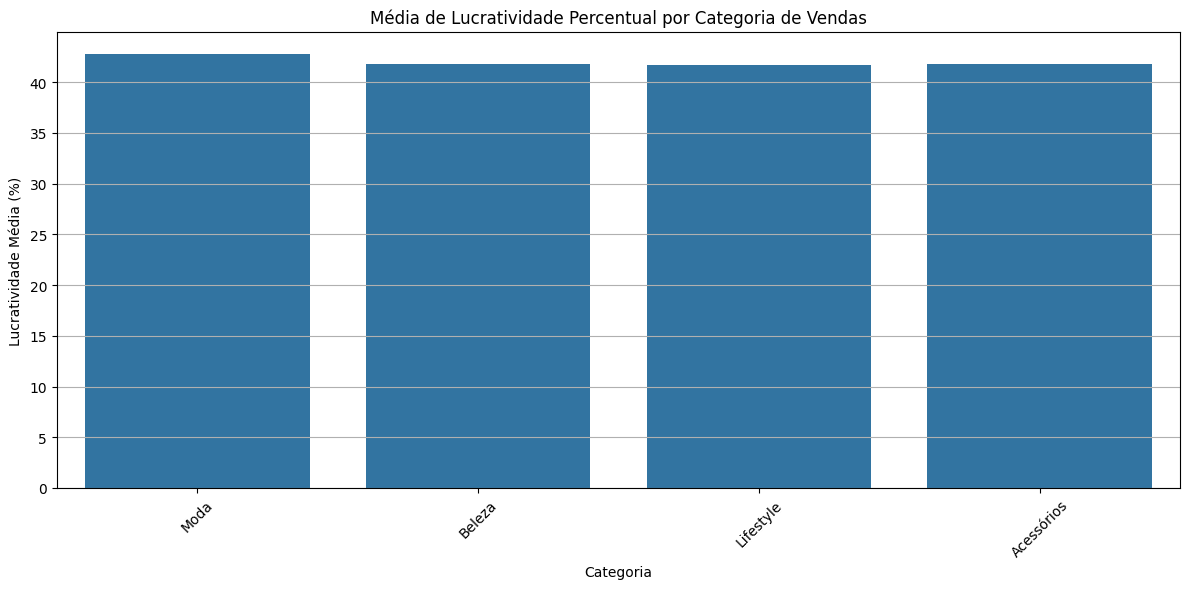


Lucratividade por Canal de Vendas:


,canal,total_receita_liquida,total_margem_contribuicao,media_lucratividade_percentual
4,Marketplace,3696219.03,1899896.05,39.060212
1,Google Ads,3376201.84,1857008.22,42.667164
3,Instagram Ads,3026872.08,1666409.34,42.530689
5,Orgânico,1990669.05,1098610.35,43.055584
2,Influenciador,1894292.07,1050455.63,44.588880
6,TikTok Ads,1795941.95,990230.35,42.839220
0,Email Marketing,1752112.12,971970.32,43.398948


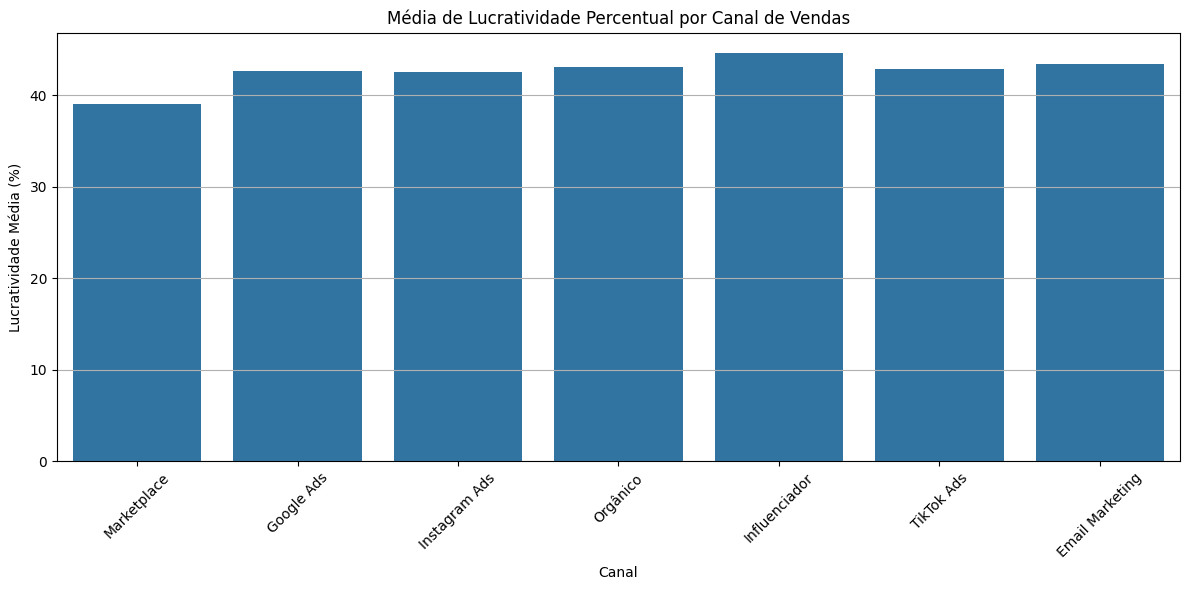


Top 10 Produtos com Menor Média de Lucratividade Percentual (onde a margem se deteriora por produto):


,produto,total_margem_contribuicao,total_receita_liquida,media_lucratividade_percentual
2871,Sombra Básico Verde,-17.59,64.08,-27.450062
100,Base Líquida Exclusivo Azul,380.36,944.07,-8.499152
504,Caderno Edição Limitada Vermelho,85.09,402.35,-8.460183
332,Blush Delicado Azul,-5.48,83.61,-6.554240
882,Chapéu Delicado Branco,-6.46,49.53,-6.521300
2247,Planta Artificial Artesanal Verde,453.28,1207.12,-5.244770
157,Batom Básico Preto,-12.11,77.91,-5.181192
1820,Lenço Oversize Branco,232.79,653.89,-3.051143
3086,Top Oversize Verde,28.16,299.84,-2.959526
219,Batom Sustentável Verde,147.23,549.86,0.384785


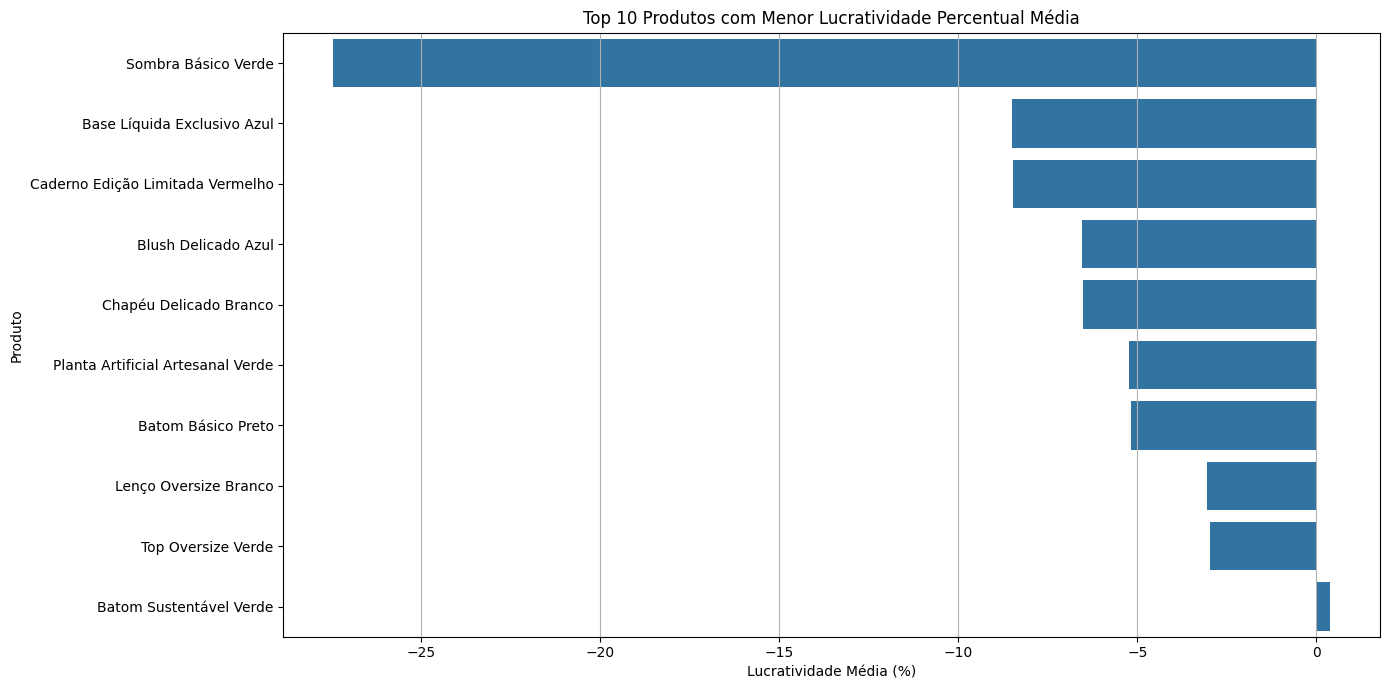


Top 10 Produtos com Menor Margem de Contribuição Total (maior impacto negativo):


,produto,total_margem_contribuicao,total_receita_liquida,media_lucratividade_percentual
2871,Sombra Básico Verde,-17.59,64.08,-27.450062
157,Batom Básico Preto,-12.11,77.91,-5.181192
882,Chapéu Delicado Branco,-6.46,49.53,-6.521300
332,Blush Delicado Azul,-5.48,83.61,-6.554240
715,Camisa Social Sport Verde,0.00,0.00,0.000000
3009,Sérum Facial Sport Nude,0.00,0.00,0.000000
3398,Óleo Corporal Slim Prata,0.00,0.00,0.000000
47,Almofada Premium Verde,0.00,0.00,0.000000
2923,Sombra Slim Prata,0.00,0.00,0.000000
127,Base Líquida Premium Rosa,0.00,0.00,0.000000


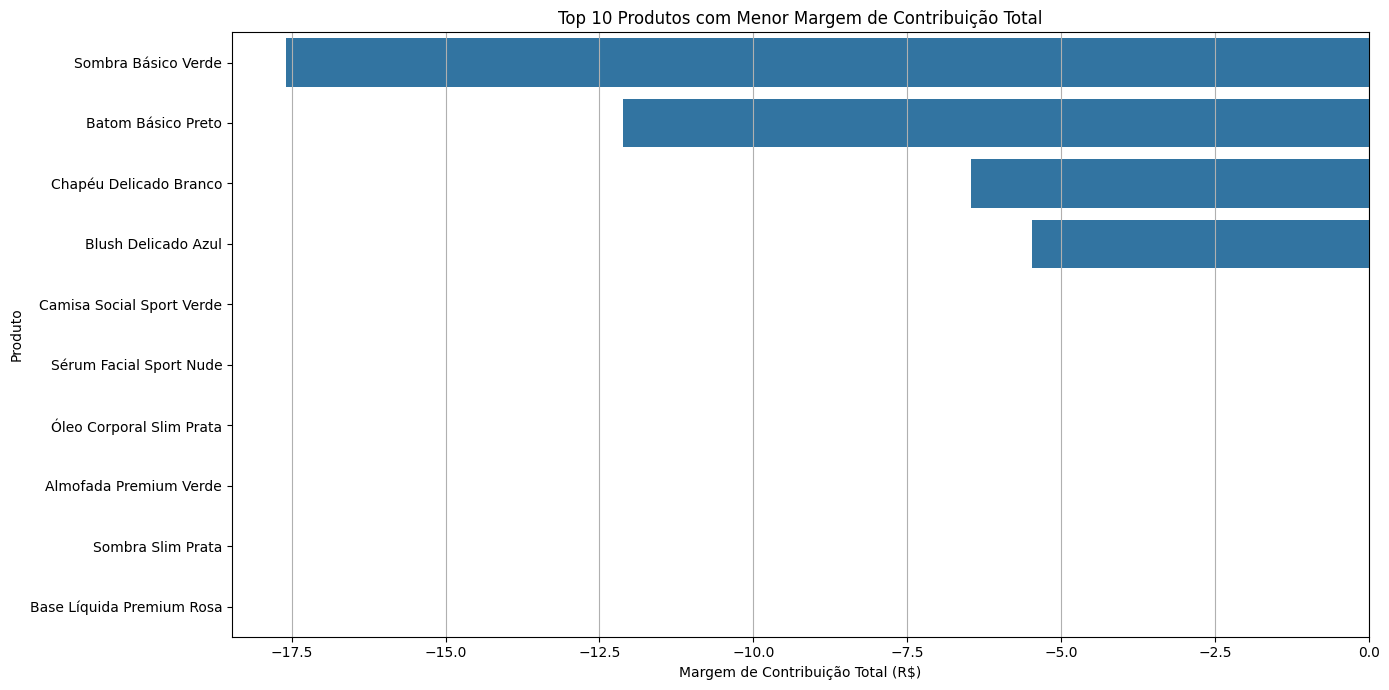

In [ ]:
# 1. Lucratividade por Categoria de Vendas
category_profit = df_merged.groupby('categoria_merged').agg(
    total_receita_liquida=('receita_liquida', 'sum'),
    total_margem_contribuicao=('margem_contribuicao', 'sum'),
    media_lucratividade_percentual=('lucratividade_percentual', 'mean')
).reset_index().sort_values(by='total_margem_contribuicao', ascending=False)

print("\nLucratividade por Categoria de Vendas:")
display(category_profit)

plt.figure(figsize=(12, 6))
sns.barplot(x='categoria_merged', y='media_lucratividade_percentual', data=category_profit)
plt.title('Média de Lucratividade Percentual por Categoria de Vendas')
plt.xlabel('Categoria')
plt.ylabel('Lucratividade Média (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 2. Lucratividade por Canal de Vendas
channel_profit = df_merged.groupby('canal').agg(
    total_receita_liquida=('receita_liquida', 'sum'),
    total_margem_contribuicao=('margem_contribuicao', 'sum'),
    media_lucratividade_percentual=('lucratividade_percentual', 'mean')
).reset_index().sort_values(by='total_margem_contribuicao', ascending=False)

print("\nLucratividade por Canal de Vendas:")
display(channel_profit)

plt.figure(figsize=(12, 6))
sns.barplot(x='canal', y='media_lucratividade_percentual', data=channel_profit)
plt.title('Média de Lucratividade Percentual por Canal de Vendas')
plt.xlabel('Canal')
plt.ylabel('Lucratividade Média (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 3. Produtos com Maior Perda de Margem (Top 10 menores margens)
# Considerando margem de contribuição por item
product_margin = df_merged.groupby('produto').agg(
    total_margem_contribuicao=('margem_contribuicao', 'sum'),
    total_receita_liquida=('receita_liquida', 'sum'),
    media_lucratividade_percentual=('lucratividade_percentual', 'mean')
).reset_index()

# Filtrar produtos com receita líquida positiva para evitar artefatos de produtos devolvidos sem vendas efetivas
product_margin_filtered = product_margin[product_margin['total_receita_liquida'] > 0]

worst_products_by_margin = product_margin_filtered.sort_values(by='media_lucratividade_percentual', ascending=True).head(10)

print("\nTop 10 Produtos com Menor Média de Lucratividade Percentual (onde a margem se deteriora por produto):")
display(worst_products_by_margin)

plt.figure(figsize=(14, 7))
sns.barplot(x='media_lucratividade_percentual', y='produto', data=worst_products_by_margin)
plt.title('Top 10 Produtos com Menor Lucratividade Percentual Média')
plt.xlabel('Lucratividade Média (%)')
plt.ylabel('Produto')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# 4. Produtos com maior impacto negativo na margem de contribuição total (Top 10 menores margens totais)
worst_products_by_total_margin = product_margin.sort_values(by='total_margem_contribuicao', ascending=True).head(10)

print("\nTop 10 Produtos com Menor Margem de Contribuição Total (maior impacto negativo):")
display(worst_products_by_total_margin)

plt.figure(figsize=(14, 7))
sns.barplot(x='total_margem_contribuicao', y='produto', data=worst_products_by_total_margin)
plt.title('Top 10 Produtos com Menor Margem de Contribuição Total')
plt.xlabel('Margem de Contribuição Total (R$)')
plt.ylabel('Produto')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

#### 2.2.3 Impacto de Descontos, Fretes e Devoluções na Margem

Vamos analisar como descontos concedidos, custos de frete e devoluções impactam a receita líquida e a margem de contribuição.


Impacto dos Descontos na Lucratividade:


,com_desconto,total_receita_liquida,total_margem_contribuicao,media_lucratividade_percentual
0,False,12284897.30,7152500.99,43.266852
1,True,5247410.84,2382079.27,39.588583


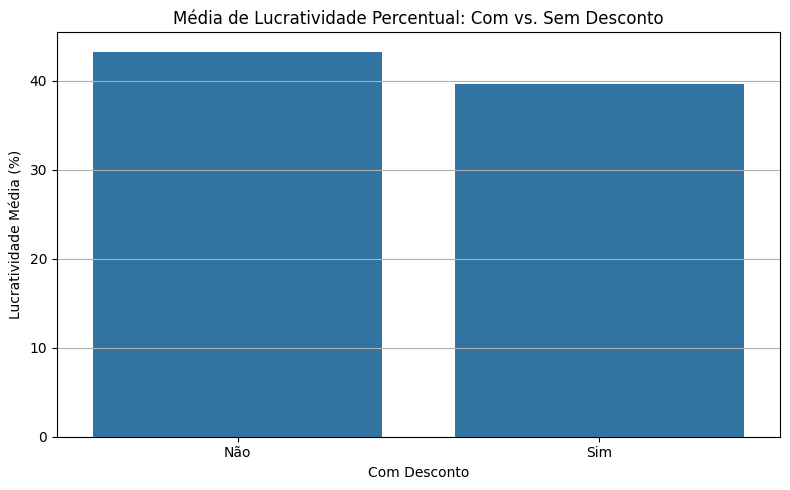

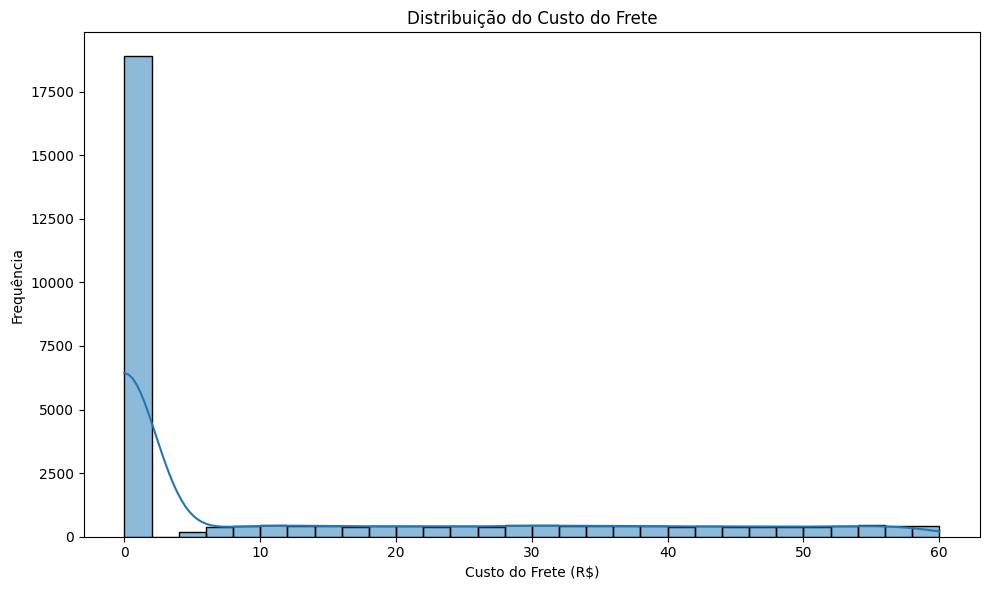


Correlação entre Custo do Frete e Margem de Contribuição: -0.27

Impacto Total das Devoluções (Receita e Margem Perdidas):


,receita_bruta,margem_contribuicao,quantidade
total_receita_bruta_perdida,0.0,NaN,NaN
total_margem_perdida,NaN,0.0,NaN
num_itens_devolvidos,NaN,NaN,16000.0



Principais Motivos de Devolução:


,Motivo da Devolução,Contagem
0,Produto com defeito,1145
1,Tamanho errado,1135
2,Atraso na entrega,906
3,Não gostei,728
4,Arrependimento,641


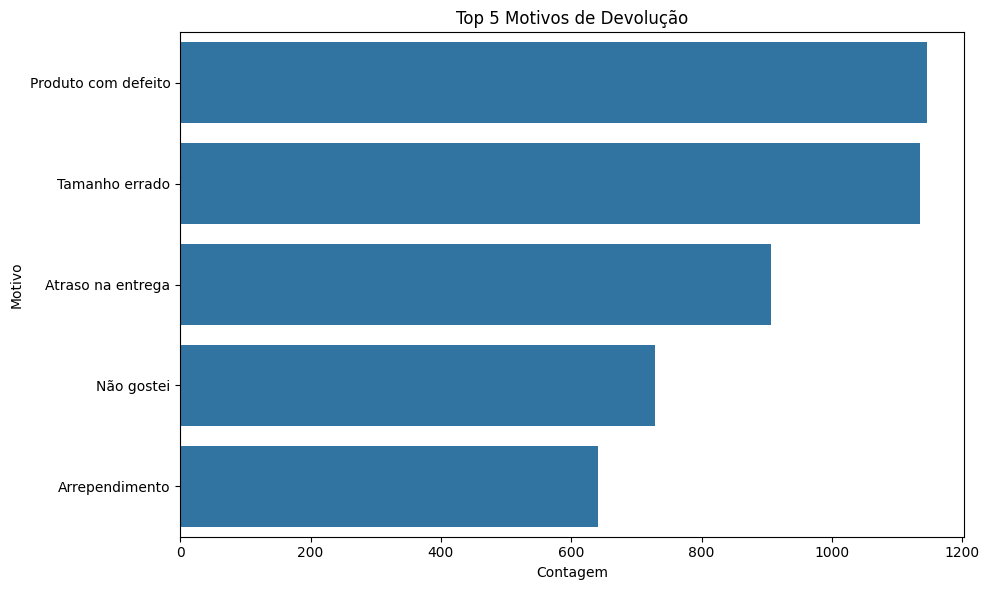

In [ ]:
# 1. Impacto de Descontos
# Vamos comparar a lucratividade de vendas com e sem desconto

df_merged['com_desconto'] = df_merged['desconto_reais'] > 0

discount_impact = df_merged.groupby('com_desconto').agg(
    total_receita_liquida=('receita_liquida', 'sum'),
    total_margem_contribuicao=('margem_contribuicao', 'sum'),
    media_lucratividade_percentual=('lucratividade_percentual', 'mean')
).reset_index()

print("\nImpacto dos Descontos na Lucratividade:")
display(discount_impact)

plt.figure(figsize=(8, 5))
sns.barplot(x='com_desconto', y='media_lucratividade_percentual', data=discount_impact)
plt.title('Média de Lucratividade Percentual: Com vs. Sem Desconto')
plt.xlabel('Com Desconto')
plt.ylabel('Lucratividade Média (%)')
plt.xticks(ticks=[0, 1], labels=['Não', 'Sim'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 2. Impacto do Custo do Frete
# Vamos analisar a distribuição do custo do frete e sua relação com a margem

plt.figure(figsize=(10, 6))
sns.histplot(df_merged['custo_frete'].dropna(), bins=30, kde=True)
plt.title('Distribuição do Custo do Frete')
plt.xlabel('Custo do Frete (R$)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Análise de correlação entre custo do frete e margem de contribuição
print(f"\nCorrelação entre Custo do Frete e Margem de Contribuição: {df_merged['custo_frete'].corr(df_merged['margem_contribuicao']):.2f}")

# 3. Impacto das Devoluções
# Já tratamos as devoluções zerando a receita e margem, mas vamos sumarizar o impacto total

de_volucao_summary = df_merged[df_merged['devolvido'] == True].agg(
    total_receita_bruta_perdida=('receita_bruta', 'sum'),
    total_margem_perdida=('margem_contribuicao', 'sum'),
    num_itens_devolvidos=('quantidade', 'sum')
)

print("\nImpacto Total das Devoluções (Receita e Margem Perdidas):")
display(de_volucao_summary)

# Podemos também analisar os motivos de devolução mais frequentes para identificar problemas recorrentes
return_reasons = df_merged[df_merged['devolvido'] == True]['motivo_devolucao'].value_counts().reset_index()
return_reasons.columns = ['Motivo da Devolução', 'Contagem']

print("\nPrincipais Motivos de Devolução:")
display(return_reasons)

plt.figure(figsize=(10, 6))
sns.barplot(x='Contagem', y='Motivo da Devolução', data=return_reasons.head(5))
plt.title('Top 5 Motivos de Devolução')
plt.xlabel('Contagem')
plt.ylabel('Motivo')
plt.tight_layout()
plt.show()

### 2.3 Marketing e Qualidade da Aquisição

Nesta seção, vamos investigar as hipóteses relacionadas ao marketing e à qualidade da aquisição de clientes. O objetivo é entender quais canais e campanhas geram maior receita, volume, e principalmente, clientes com maior valor ao longo do tempo. Para isso, será crucial integrar os dados do `df_marketing` com o `df_merged` de forma estratégica, considerando a granularidade e os períodos das campanhas.

#### 2.3.1 Integração e Preparação dos Dados de Marketing

Vamos agora integrar as informações do `df_marketing` ao nosso `df_merged`. A principal dificuldade aqui é que as informações de marketing são por campanha e canal, com datas de início e fim, enquanto as vendas são por `order_id` e `data_pedido`. Precisaremos criar uma lógica para atribuir a campanha correta a cada pedido, se houver um match de canal e período.

In [ ]:
# Para integrar o marketing, precisamos definir uma lógica de atribuição.
# A atribuição padrão que temos no df_marketing é 'First Click', 'Last Click', 'Linear', etc.
# No entanto, para relacionar diretamente com as vendas, vamos considerar a 'data_pedido' e o 'canal'.

# Vamos primeiro garantir que as colunas de data em df_marketing e df_merged estejam no formato datetime.
# df_merged['data_pedido'] já foi convertido.
df_marketing['data_inicio'] = pd.to_datetime(df_marketing['data_inicio'], errors='coerce')
df_marketing['data_fim'] = pd.to_datetime(df_marketing['data_fim'], errors='coerce')

# Criar uma cópia do df_merged para evitar modificar o original em operações complexas de merge
df_merged_marketing = df_merged.copy()

# A forma mais precisa de atribuir uma campanha a uma venda é se a venda ocorreu dentro do período da campanha
# e pelo mesmo canal. Isso geralmente requer um merge mais complexo ou uma atribuição condicional.

# Vamos tentar um merge condicional. Primeiro, expandimos o df_marketing para cada dia de duração da campanha,
# mas isso pode ser computacionalmente caro. Uma alternativa mais simples é fazer um merge por 'canal'
# e depois filtrar pelas datas, ou agrupar os dados de marketing por canal e usá-los para análises mais agregadas.

# Para evitar a explosão de linhas e manter a granularidade do pedido, vamos primeiro focar em uma análise agregada de marketing por canal,
# e depois, se necessário, tentar atribuir campanhas específicas aos pedidos.

# Agrupar as métricas de marketing por canal
marketing_summary_by_channel = df_marketing.groupby('canal').agg(
    total_investimento=('investimento_reais', 'sum'),
    total_impressoes=('impressoes', 'sum'),
    total_cliques=('cliques', 'sum'),
    total_conversoes=('conversoes', 'sum'),
    media_roas=('roas', 'mean'), # Média de ROAS, cuidado com a interpretação aqui
    total_receita_gerada_marketing=('receita_gerada', 'sum'),
    media_cac=('cac', 'mean') # Média de CAC
).reset_index()

print("Sumário de Marketing Agregado por Canal:")
display(marketing_summary_by_channel)

# Agora, vamos juntar essas informações de marketing agregadas por canal ao df_merged.
# Usaremos 'canal' como chave de junção.
df_merged_marketing = pd.merge(
    df_merged_marketing,
    marketing_summary_by_channel,
    on='canal',
    how='left'
)

print("\nDataFrame mesclado com dados de marketing agregados (primeiras 5 linhas):")
display(df_merged_marketing[['order_id', 'canal', 'receita_liquida', 'total_investimento', 'total_impressoes', 'media_roas']].head())

print("\nInformações do DataFrame mesclado com marketing (amostra de colunas):")
df_merged_marketing.info()

Sumário de Marketing Agregado por Canal:


,canal,total_investimento,total_impressoes,total_cliques,total_conversoes,media_roas,total_receita_gerada_marketing,media_cac
0,Email Marketing,29700531.98,7190708958,248127946,16563197,2.997897,9.104621e+07,4.291546
1,Google Ads,30224839.25,7276888260,250841055,16118323,3.513536,1.065574e+08,4.269627
2,Influenciador,28061599.02,6734376424,241081421,15940484,7.691548,2.175780e+08,4.173484
3,Instagram Ads,30165772.33,7036628198,233280842,15360484,4.426390,1.359386e+08,4.716699
4,Marketplace,32682629.69,8028787619,271482915,17894187,3.004519,9.879591e+07,4.385963
5,Orgânico,29808867.75,7090741183,234763601,16401820,2.993434,8.964926e+07,4.655960
6,TikTok Ads,29770101.07,7258701523,258038032,17009948,4.667111,1.390634e+08,3.954672



DataFrame mesclado com dados de marketing agregados (primeiras 5 linhas):


,order_id,canal,receita_liquida,total_investimento,total_impressoes,media_roas
0,ORD-036085,TikTok Ads,1960.62,29770101.07,7258701523,4.667111
1,ORD-029209,Orgânico,225.27,29808867.75,7090741183,2.993434
2,ORD-047667,Instagram Ads,2064.72,30165772.33,7036628198,4.426390
3,ORD-026951,Orgânico,676.85,29808867.75,7090741183,2.993434
4,ORD-016561,Instagram Ads,0.00,30165772.33,7036628198,4.426390



Informações do DataFrame mesclado com marketing (amostra de colunas):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30297 entries, 0 to 30296
Data columns (total 70 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   order_id                         30297 non-null  object        
 1   customer_id_merged               30297 non-null  object        
 2   sku_id                           30297 non-null  object        
 3   data_pedido                      30297 non-null  datetime64[ns]
 4   canal                            30297 non-null  object        
 5   categoria_merged                 30297 non-null  object        
 6   produto                          30297 non-null  object        
 7   quantidade                       30297 non-null  float64       
 8   preco_unitario                   30297 non-null  float64       
 9   receita_bruta                    30297 non-null  float64

#### 2.3.2 Análise de Desempenho dos Canais de Marketing

Vamos analisar o desempenho dos canais de marketing em termos de receita, volume, e eficiência (CAC, ROAS). A integração atual nos permite correlacionar as vendas com as métricas agregadas por canal. Usaremos o `df_merged_marketing` para esta análise.


Análise de Desempenho dos Canais de Marketing (Agregado):


,canal,total_receita_liquida,total_margem_contribuicao,media_lucratividade_percentual,total_investimento_marketing,total_receita_gerada_marketing,media_roas_marketing,media_cac_marketing,roas_vendas_calculado,roi_marketing_calculado
4,Marketplace,3696219.03,1899896.05,39.060212,32682629.69,9.879591e+07,3.004519,4.385963,0.113094,-94.186832
1,Google Ads,3376201.84,1857008.22,42.667164,30224839.25,1.065574e+08,3.513536,4.269627,0.111703,-93.856020
3,Instagram Ads,3026872.08,1666409.34,42.530689,30165772.33,1.359386e+08,4.426390,4.716699,0.100341,-94.475827
5,Orgânico,1990669.05,1098610.35,43.055584,29808867.75,8.964926e+07,2.993434,4.655960,0.066781,-96.314485
2,Influenciador,1894292.07,1050455.63,44.588880,28061599.02,2.175780e+08,7.691548,4.173484,0.067505,-96.256608
6,TikTok Ads,1795941.95,990230.35,42.839220,29770101.07,1.390634e+08,4.667111,3.954672,0.060327,-96.673742
0,Email Marketing,1752112.12,971970.32,43.398948,29700531.98,9.104621e+07,2.997897,4.291546,0.058993,-96.727431


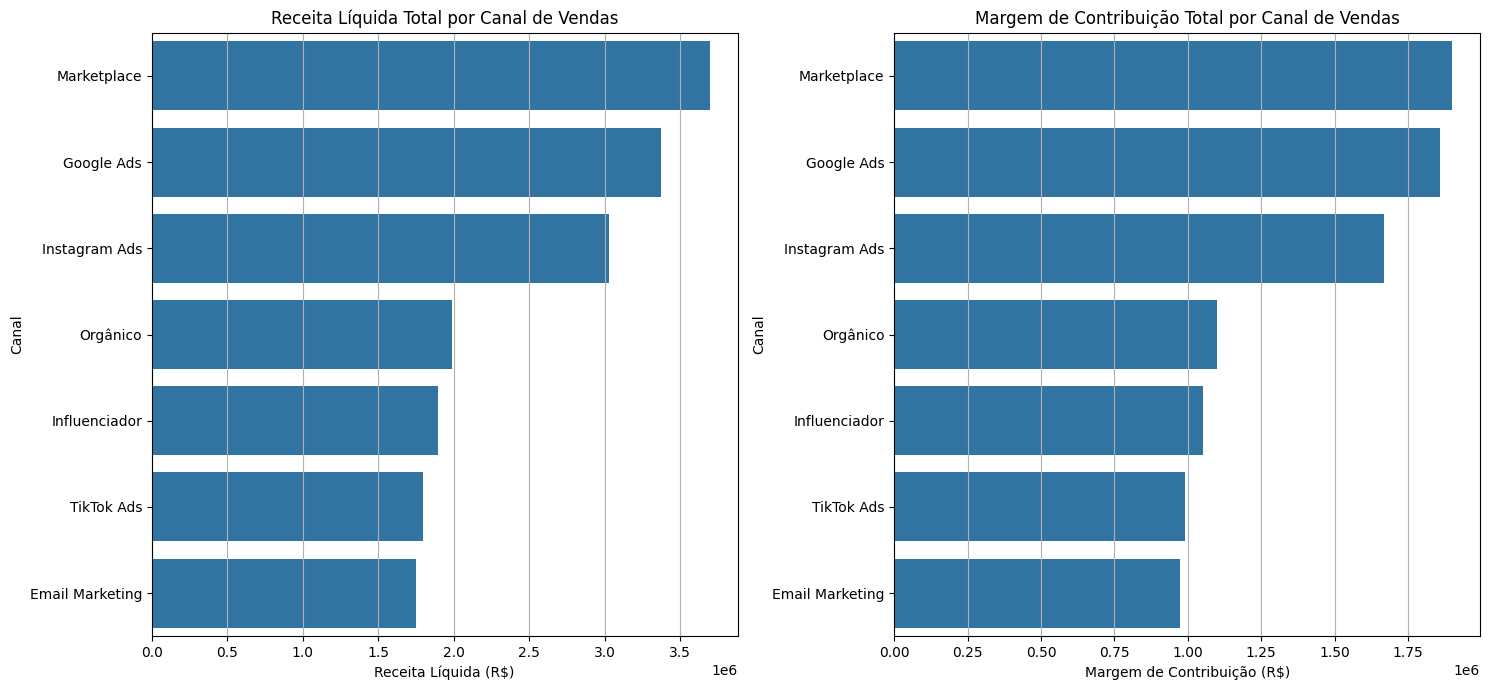

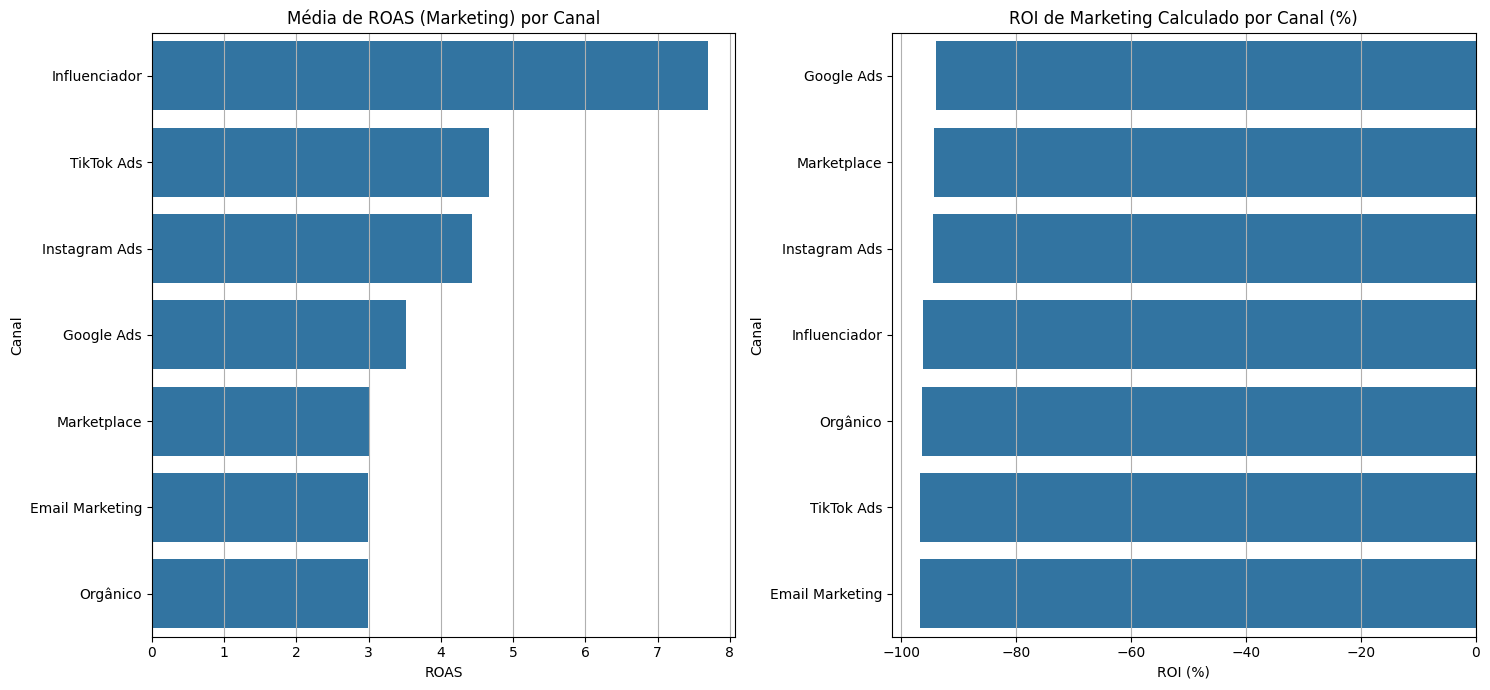

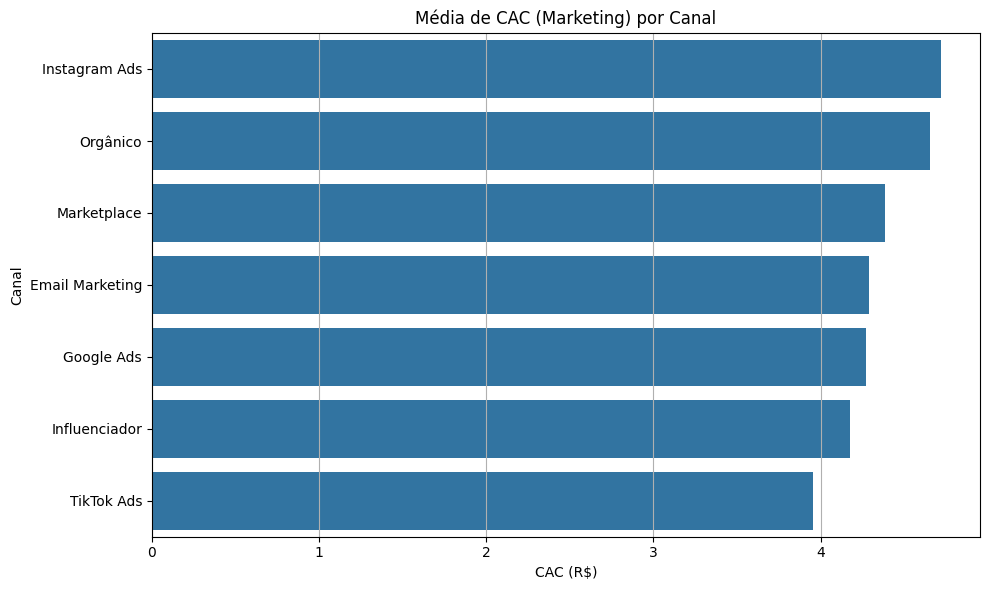

In [ ]:
# 1. Análise Comparativa de Receita Líquida e Margem por Canal (com dados de marketing)
# Vamos agrupar o df_merged_marketing pelo canal para ter uma visão consolidada de vendas e marketing

channel_performance = df_merged_marketing.groupby('canal').agg(
    total_receita_liquida=('receita_liquida', 'sum'),
    total_margem_contribuicao=('margem_contribuicao', 'sum'),
    media_lucratividade_percentual=('lucratividade_percentual', 'mean'),
    total_investimento_marketing=('total_investimento', 'mean'), # 'mean' aqui para pegar o valor agregado do canal
    total_receita_gerada_marketing=('total_receita_gerada_marketing', 'mean'), # 'mean' para pegar o valor agregado do canal
    media_roas_marketing=('media_roas', 'mean'), # 'mean' para pegar o valor médio do canal
    media_cac_marketing=('media_cac', 'mean') # 'mean' para pegar o valor médio do canal
).reset_index()

# Calcular o ROAS 'real' (receita das vendas / investimento de marketing)
channel_performance['roas_vendas_calculado'] = (
    channel_performance['total_receita_liquida'] / (channel_performance['total_investimento_marketing'] + 1e-9)
)

# Calcular o ROI de marketing (margem de contribuição gerada - investimento) / investimento
channel_performance['roi_marketing_calculado'] = (
    (channel_performance['total_margem_contribuicao'] - channel_performance['total_investimento_marketing']) /
    (channel_performance['total_investimento_marketing'] + 1e-9)
) * 100

print("\nAnálise de Desempenho dos Canais de Marketing (Agregado):")
display(channel_performance.sort_values(by='total_receita_liquida', ascending=False))

# Visualizar Receita Líquida e Margem de Contribuição por Canal
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='total_receita_liquida', y='canal', data=channel_performance.sort_values(by='total_receita_liquida', ascending=False))
plt.title('Receita Líquida Total por Canal de Vendas')
plt.xlabel('Receita Líquida (R$)')
plt.ylabel('Canal')
plt.grid(axis='x')

plt.subplot(1, 2, 2)
sns.barplot(x='total_margem_contribuicao', y='canal', data=channel_performance.sort_values(by='total_margem_contribuicao', ascending=False))
plt.title('Margem de Contribuição Total por Canal de Vendas')
plt.xlabel('Margem de Contribuição (R$)')
plt.ylabel('Canal')
plt.grid(axis='x')

plt.tight_layout()
plt.show()

# Visualizar ROAS e ROI por Canal
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='media_roas_marketing', y='canal', data=channel_performance.sort_values(by='media_roas_marketing', ascending=False))
plt.title('Média de ROAS (Marketing) por Canal')
plt.xlabel('ROAS')
plt.ylabel('Canal')
plt.grid(axis='x')

plt.subplot(1, 2, 2)
sns.barplot(x='roi_marketing_calculado', y='canal', data=channel_performance.sort_values(by='roi_marketing_calculado', ascending=False))
plt.title('ROI de Marketing Calculado por Canal (%)')
plt.xlabel('ROI (%)')
plt.ylabel('Canal')
plt.grid(axis='x')

plt.tight_layout()
plt.show()

# Visualizar CAC por Canal
plt.figure(figsize=(10, 6))
sns.barplot(x='media_cac_marketing', y='canal', data=channel_performance.sort_values(by='media_cac_marketing', ascending=False))
plt.title('Média de CAC (Marketing) por Canal')
plt.xlabel('CAC (R$)')
plt.ylabel('Canal')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### 2.4 Operações

Nesta seção, vamos investigar quais eventos operacionais apresentam maior impacto financeiro, se existe concentração de problemas em determinados produtos/SKUs e quantificar o impacto desses eventos sobre receita, margem e pedidos.

#### 2.4.1 Análise do Impacto de Eventos Operacionais (Devoluções, Atrasos)

Já abordamos as devoluções financeiramente na seção de margem, mas podemos aprofundar na análise dos motivos de devolução e seu impacto, além de olhar para outros problemas como atrasos.


Principais Motivos de Devolução (para contextualização da hipótese de Operações):


,Motivo da Devolução,Contagem
0,Produto com defeito,1145
1,Tamanho errado,1135
2,Atraso na entrega,906
3,Não gostei,728
4,Arrependimento,641


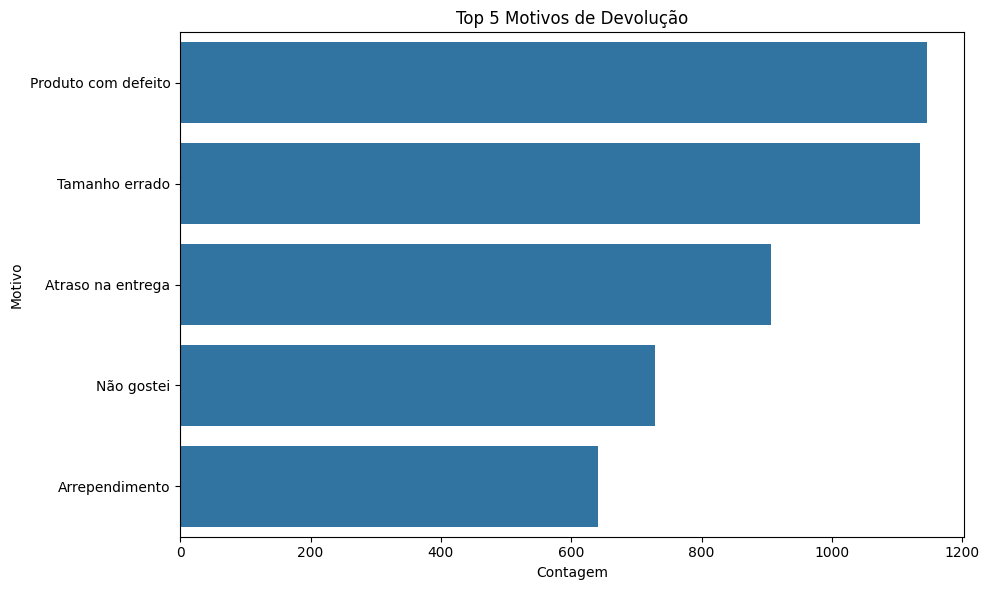


Impacto de Pedidos com Atraso na Entrega (Limiar > 168 horas):


,atraso_entrega,num_pedidos,total_receita_liquida,total_margem_contribuicao,media_lucratividade_percentual
0,False,30297,17532308.14,9534580.26,42.152821



Top 10 Produtos com Maior Incidência de Atrasos:


,produto,num_pedidos_atrasados


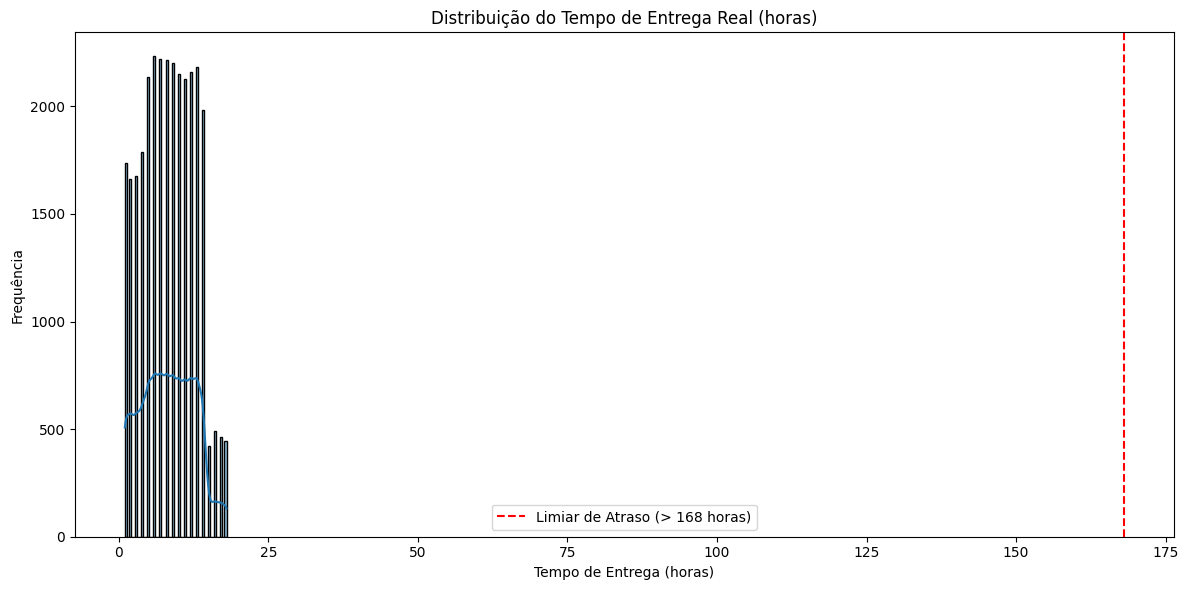

In [ ]:
# Re-analisar os motivos de devolução (já calculados anteriormente, mas vamos exibi-los novamente para contexto)
print("\nPrincipais Motivos de Devolução (para contextualização da hipótese de Operações):")
display(return_reasons)

plt.figure(figsize=(10, 6))
sns.barplot(x='Contagem', y='Motivo da Devolução', data=return_reasons.head(5))
plt.title('Top 5 Motivos de Devolução')
plt.xlabel('Contagem')
plt.ylabel('Motivo')
plt.tight_layout()
plt.show()

# Análise de pedidos com 'tempo_entrega_real' alto (indicativo de atraso)
# Vamos definir um limiar para 'atraso' - por exemplo, acima da média + 1 desvio padrão, ou um valor fixo se soubermos a expectativa.
# Por simplicidade, vamos considerar um percentil superior ou um valor acima da média para identificar potenciais atrasos.

# Calculando a média e o desvio padrão do tempo de entrega real
mean_delivery_time = df_merged['tempo_entrega_real'].mean()
std_delivery_time = df_merged['tempo_entrega_real'].std()

# Definir um atraso como qualquer entrega que leve mais de (média + 1 desvio padrão) ou um valor razoável para o negócio (ex: 7 dias = 168 horas)
# Vamos usar um limiar de 7 dias (168 horas) para atraso, considerando que muitos e-commerce buscam entregas rápidas.
late_delivery_threshold = 7 * 24 # 7 dias em horas

df_merged['atraso_entrega'] = df_merged['tempo_entrega_real'] > late_delivery_threshold

# Comparar métricas de pedidos com e sem atraso
late_delivery_impact = df_merged.groupby('atraso_entrega').agg(
    num_pedidos=('order_id', 'count'),
    total_receita_liquida=('receita_liquida', 'sum'),
    total_margem_contribuicao=('margem_contribuicao', 'sum'),
    media_lucratividade_percentual=('lucratividade_percentual', 'mean')
).reset_index()

print(f"\nImpacto de Pedidos com Atraso na Entrega (Limiar > {late_delivery_threshold} horas):")
display(late_delivery_impact)

# Análise por SKU/Produto com maior incidência de atrasos
late_products = df_merged[df_merged['atraso_entrega'] == True].groupby('produto').agg(
    num_pedidos_atrasados=('order_id', 'count')
).reset_index().sort_values(by='num_pedidos_atrasados', ascending=False)

print("\nTop 10 Produtos com Maior Incidência de Atrasos:")
display(late_products.head(10))

# Visualizar a distribuição do tempo de entrega
plt.figure(figsize=(12, 6))
sns.histplot(df_merged['tempo_entrega_real'].dropna(), bins=50, kde=True)
plt.axvline(x=late_delivery_threshold, color='r', linestyle='--', label=f'Limiar de Atraso (> {late_delivery_threshold} horas)')
plt.title('Distribuição do Tempo de Entrega Real (horas)')
plt.xlabel('Tempo de Entrega (horas)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

### 2.5 Atendimento

Nesta seção, vamos analisar os dados de atendimento para entender os principais temas dos problemas dos clientes, quais categorias de problemas estão associadas a maior tempo de resposta ou insatisfação (medida pelo CSAT) e identificar possíveis oportunidades de melhoria ou automação.

#### 2.5.1 Análise de Temas e Eficiência do Atendimento

Vamos começar explorando a frequência dos temas de atendimento (`categoria_problema`), o tempo de primeira resposta e a satisfação do cliente (`nota_csat`).


Frequência dos Temas de Atendimento:


,Categoria do Problema,Contagem
0,Onde está meu pedido?,3724
1,Defeito,2196
2,Troca de Tamanho,1862
3,Dúvida Técnica,1854
4,Pagamento não aprovado,1550
5,Elogio,1218


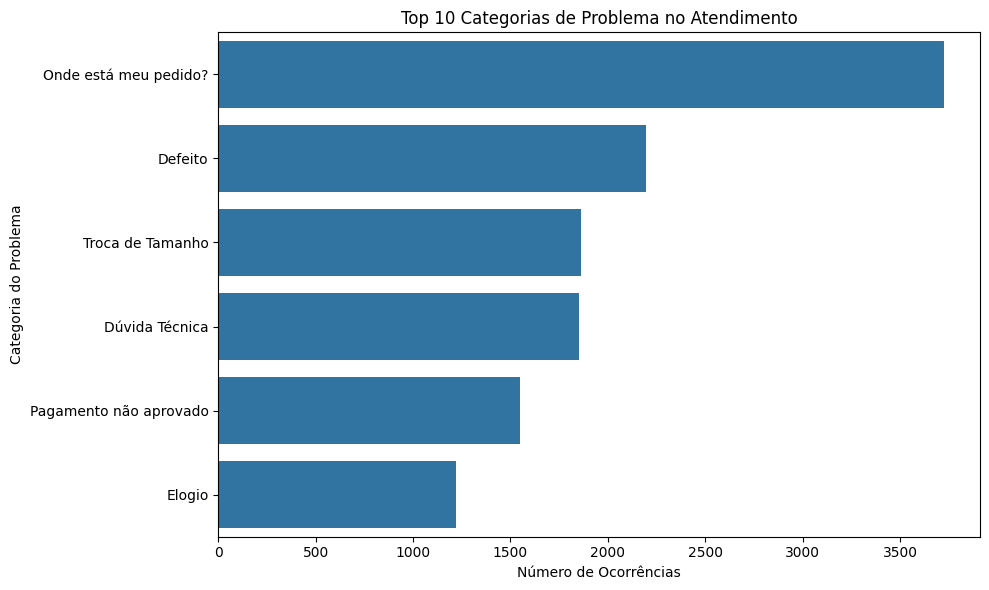


Tempo de Resposta Médio e CSAT Médio por Categoria de Problema:


,categoria_problema,media_tempo_resposta_minutos,media_nota_csat,num_tickets
3,Onde está meu pedido?,132.009130,2.987111,3724
0,Defeito,134.451730,2.806922,2196
5,Troca de Tamanho,136.938776,3.001611,1862
1,Dúvida Técnica,137.159655,3.844121,1854
4,Pagamento não aprovado,134.501935,2.989032,1550
2,Elogio,131.986043,4.571429,1218


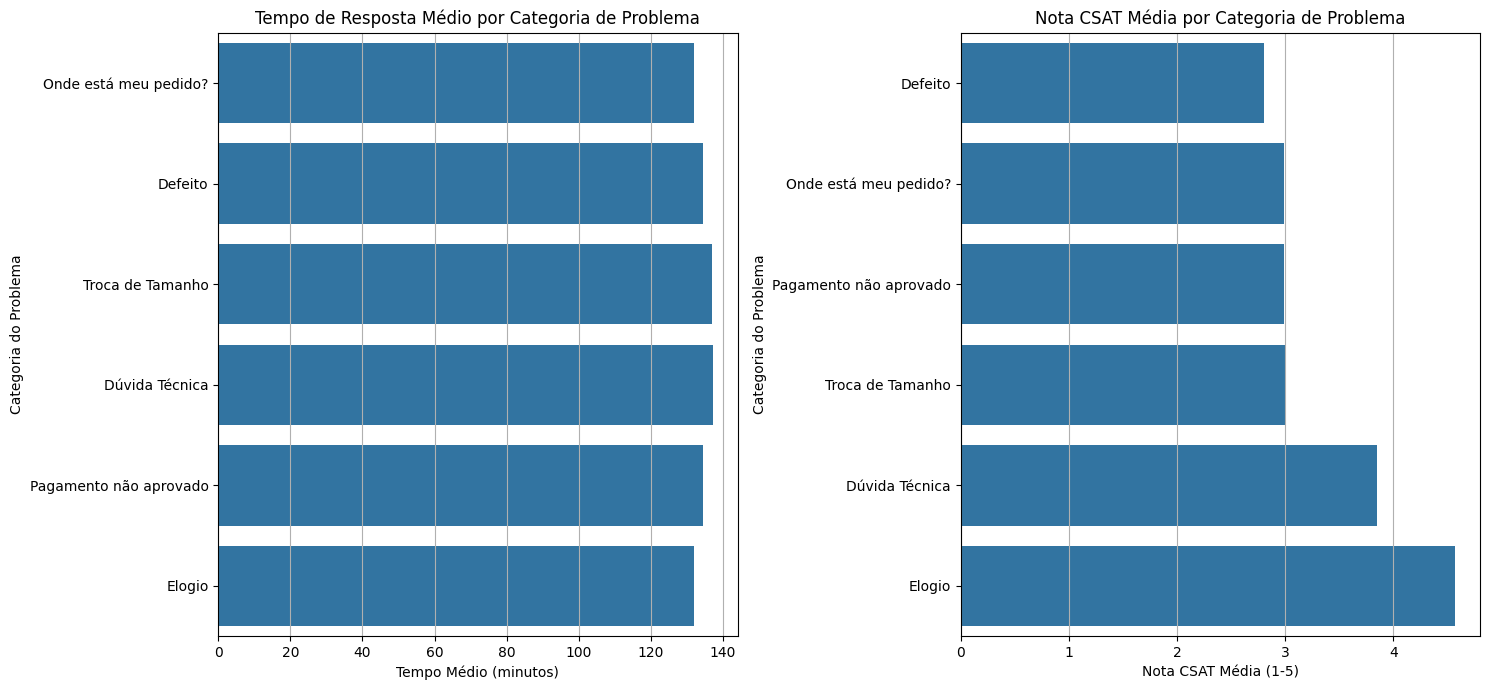


Impacto de Pedidos com Atendimento na Margem de Contribuição:


,teve_atendimento,num_pedidos,total_receita_liquida,total_margem_contribuicao,media_lucratividade_percentual
0,False,17893,10339878.95,5615083.85,42.227630
1,True,12404,7192429.19,3919496.41,42.044908


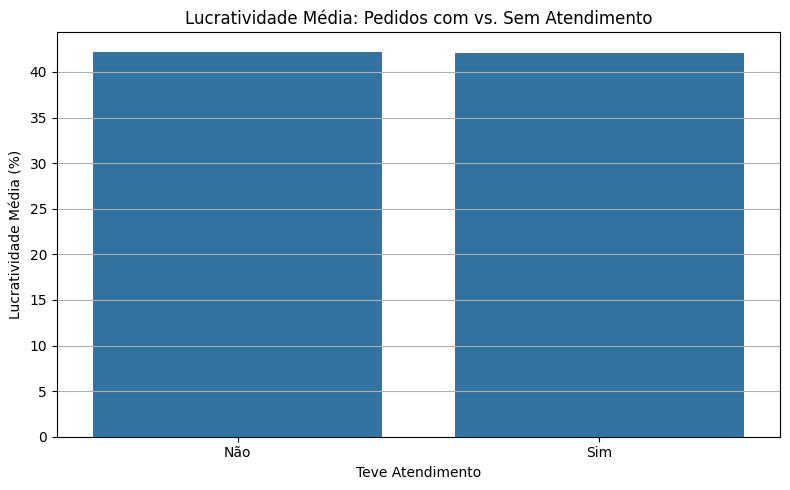

In [ ]:
# 1. Frequência dos Temas de Atendimento

problem_categories = df_merged['categoria_problema'].value_counts().reset_index()
problem_categories.columns = ['Categoria do Problema', 'Contagem']

print("\nFrequência dos Temas de Atendimento:")
display(problem_categories)

plt.figure(figsize=(10, 6))
sns.barplot(x='Contagem', y='Categoria do Problema', data=problem_categories.head(10))
plt.title('Top 10 Categorias de Problema no Atendimento')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Categoria do Problema')
plt.tight_layout()
plt.show()

# 2. Tempo de Primeira Resposta e CSAT por Categoria de Problema

# Filtrar apenas tickets que tiveram atendimento (onde nota_csat não é nula)
service_performance = df_merged.dropna(subset=['nota_csat']).groupby('categoria_problema').agg(
    media_tempo_resposta_minutos=('tempo_primeira_resposta_minutos', 'mean'),
    media_nota_csat=('nota_csat', 'mean'),
    num_tickets=('ticket_id', 'count')
).reset_index().sort_values(by='num_tickets', ascending=False)

print("\nTempo de Resposta Médio e CSAT Médio por Categoria de Problema:")
display(service_performance.head(10))

# Visualizar Tempo de Resposta por Categoria
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.barplot(x='media_tempo_resposta_minutos', y='categoria_problema', data=service_performance.head(10))
plt.title('Tempo de Resposta Médio por Categoria de Problema')
plt.xlabel('Tempo Médio (minutos)')
plt.ylabel('Categoria do Problema')
plt.grid(axis='x')

# Visualizar CSAT por Categoria
plt.subplot(1, 2, 2)
sns.barplot(x='media_nota_csat', y='categoria_problema', data=service_performance.head(10).sort_values(by='media_nota_csat', ascending=True))
plt.title('Nota CSAT Média por Categoria de Problema')
plt.xlabel('Nota CSAT Média (1-5)')
plt.ylabel('Categoria do Problema')
plt.grid(axis='x')

plt.tight_layout()
plt.show()

# 3. Impacto do Atendimento na Margem de Contribuição
# Podemos analisar a margem de contribuição de pedidos que geraram atendimento vs. os que não geraram

# Criar uma flag para indicar se o pedido teve atendimento
df_merged['teve_atendimento'] = df_merged['ticket_id'].notna()

service_impact_on_margin = df_merged.groupby('teve_atendimento').agg(
    num_pedidos=('order_id', 'count'),
    total_receita_liquida=('receita_liquida', 'sum'),
    total_margem_contribuicao=('margem_contribuicao', 'sum'),
    media_lucratividade_percentual=('lucratividade_percentual', 'mean')
).reset_index()

print("\nImpacto de Pedidos com Atendimento na Margem de Contribuição:")
display(service_impact_on_margin)

plt.figure(figsize=(8, 5))
sns.barplot(x='teve_atendimento', y='media_lucratividade_percentual', data=service_impact_on_margin)
plt.title('Lucratividade Média: Pedidos com vs. Sem Atendimento')
plt.xlabel('Teve Atendimento')
plt.ylabel('Lucratividade Média (%)')
plt.xticks(ticks=[0, 1], labels=['Não', 'Sim'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 2.6 Clientes

Nesta seção, vamos investigar os dados dos clientes para identificar segmentos que concentram maior receita e margem, perfis que apresentam maior recorrência ou sinais de risco de churn, e potenciais oportunidades de retenção, upsell ou recuperação. Para isso, vamos utilizar métricas como LTV, frequência de pedidos e informações de RFM já disponíveis.

#### 2.6.1 Análise de Segmentação e Valor do Cliente

Vamos começar explorando os segmentos RFM, LTV e o número total de pedidos para entender a distribuição de valor entre os clientes.


Análise de Clientes por Segmento RFM:


,segmento_rfm,num_clientes,total_receita,total_margem,media_ltv,media_total_pedidos
5,Promissor,102,8374557.26,4558125.25,2616.518694,10.713627
2,Em Risco,82,4676400.37,2543103.56,4467.976735,7.864606
3,Fiel,60,2634138.67,1427708.66,12828.447029,21.952084
0,Campeão,27,1373514.47,748258.77,36585.061247,59.388987
4,Hibernando,36,384594.11,209632.08,2811.943781,6.324088
1,Churn,39,89103.26,47751.94,2308.144817,4.743902


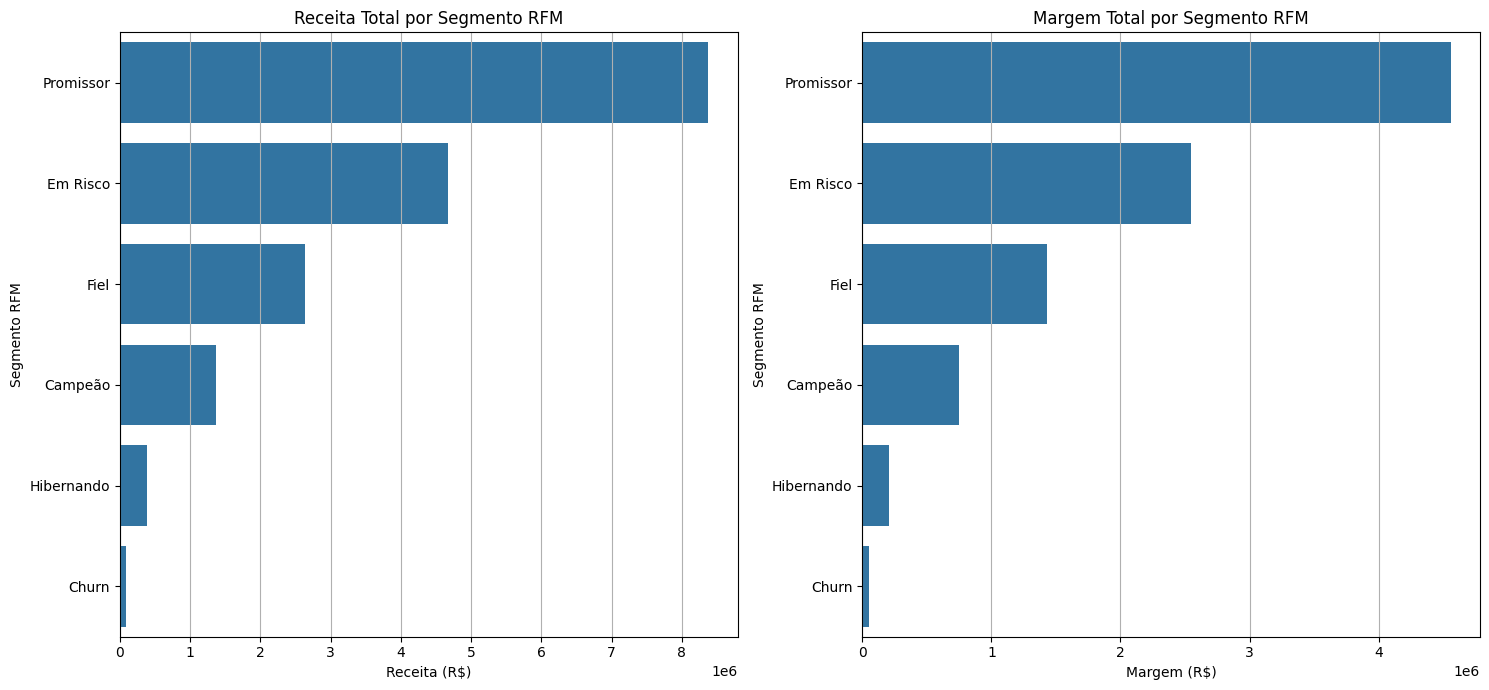


Análise de Clientes por Nível de Fidelidade:


,nivel_fidelidade,num_clientes,total_receita,total_margem,media_ltv,media_total_pedidos
0,Bronze,167,12395432.89,6743877.80,2456.725505,8.538106
3,Silver,105,3290999.91,1784526.97,11781.894551,17.665235
2,Platinum,23,1169606.07,638925.59,40125.530223,63.976129
1,Gold,51,676269.27,367249.90,18209.026414,44.574138


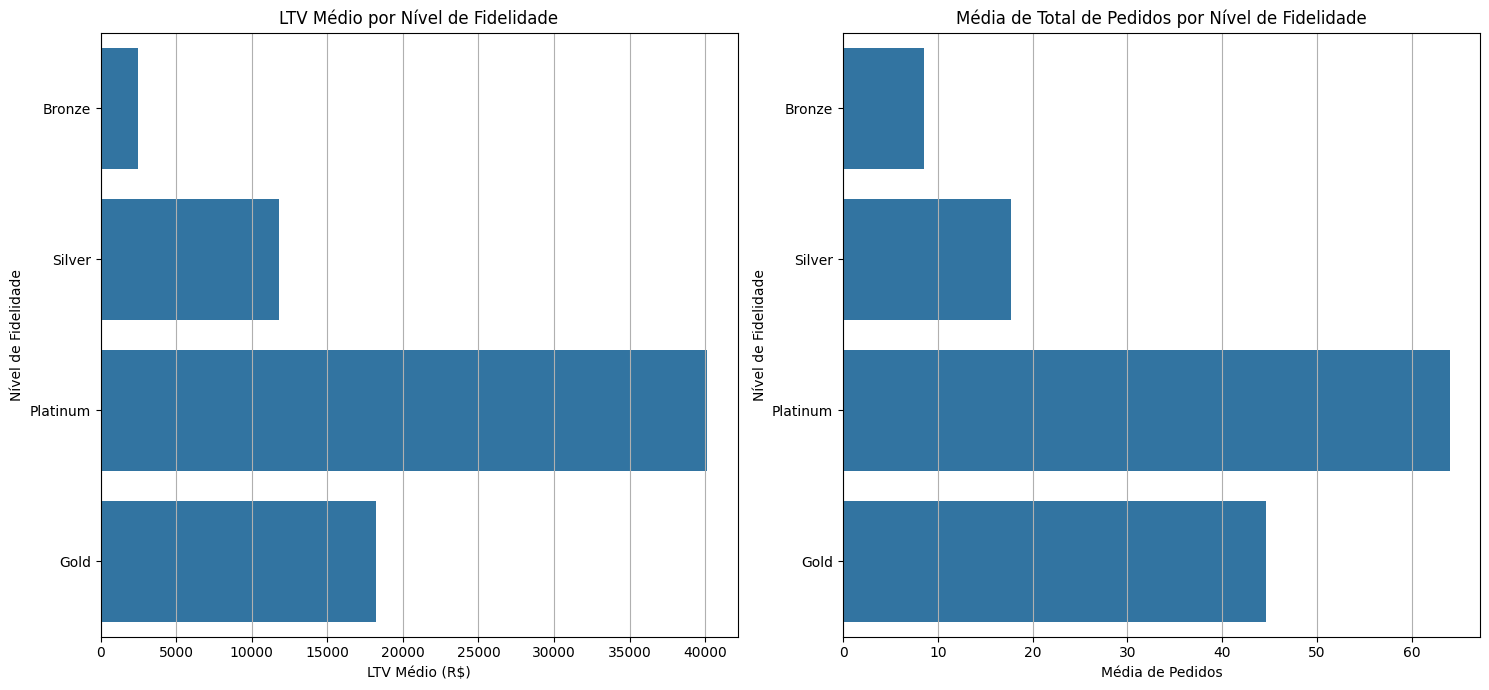

In [ ]:
# 1. Análise por Segmento RFM

rfm_segment_analysis = df_merged.groupby('segmento_rfm').agg(
    num_clientes=('customer_id_merged', 'nunique'),
    total_receita=('receita_liquida', 'sum'),
    total_margem=('margem_contribuicao', 'sum'),
    media_ltv=('ltv_acumulado', 'mean'),
    media_total_pedidos=('total_pedidos_historico', 'mean')
).reset_index().sort_values(by='total_margem', ascending=False)

print("\nAnálise de Clientes por Segmento RFM:")
display(rfm_segment_analysis)

# Visualização da Receita e Margem por Segmento RFM
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='total_receita', y='segmento_rfm', data=rfm_segment_analysis)
plt.title('Receita Total por Segmento RFM')
plt.xlabel('Receita (R$)')
plt.ylabel('Segmento RFM')
plt.grid(axis='x')

plt.subplot(1, 2, 2)
sns.barplot(x='total_margem', y='segmento_rfm', data=rfm_segment_analysis)
plt.title('Margem Total por Segmento RFM')
plt.xlabel('Margem (R$)')
plt.ylabel('Segmento RFM')
plt.grid(axis='x')

plt.tight_layout()
plt.show()

# 2. Análise por Nível de Fidelidade

loyalty_level_analysis = df_merged.groupby('nivel_fidelidade').agg(
    num_clientes=('customer_id_merged', 'nunique'),
    total_receita=('receita_liquida', 'sum'),
    total_margem=('margem_contribuicao', 'sum'),
    media_ltv=('ltv_acumulado', 'mean'),
    media_total_pedidos=('total_pedidos_historico', 'mean')
).reset_index().sort_values(by='total_margem', ascending=False)

print("\nAnálise de Clientes por Nível de Fidelidade:")
display(loyalty_level_analysis)

# Visualização da Média de LTV e Total de Pedidos por Nível de Fidelidade
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='media_ltv', y='nivel_fidelidade', data=loyalty_level_analysis)
plt.title('LTV Médio por Nível de Fidelidade')
plt.xlabel('LTV Médio (R$)')
plt.ylabel('Nível de Fidelidade')
plt.grid(axis='x')

plt.subplot(1, 2, 2)
sns.barplot(x='media_total_pedidos', y='nivel_fidelidade', data=loyalty_level_analysis)
plt.title('Média de Total de Pedidos por Nível de Fidelidade')
plt.xlabel('Média de Pedidos')
plt.ylabel('Nível de Fidelidade')
plt.grid(axis='x')

plt.tight_layout()
plt.show()

### 2.7 Gestão e Produtividade

Nesta seção final, vamos refletir sobre os processos que podem estar impactando a produtividade e a eficiência geral do negócio. Embora os dados diretos para 'gestão e produtividade' sejam limitados nas bases fornecidas, podemos inferir oportunidades de melhoria ou automação a partir dos problemas identificados nas análises anteriores (margem, marketing, operações, atendimento). O objetivo é identificar tarefas repetitivas, de alto volume ou que exigem classificação/triagem manual e que podem se beneficiar de automação ou uso de IA.

Para esta hipótese, vamos sumarizar as oportunidades identificadas nas análises anteriores.

#### 2.7.1 Oportunidades de Melhoria e Automação Inferidas das Análises Anteriores

Vamos listar os pontos levantados nas análises de Margem, Marketing, Operações e Atendimento que podem indicar ineficiências de gestão ou oportunidades de automação.

In [ ]:
print("\n--- Oportunidades de Melhoria e Automação (Gestão e Produtividade) ---\n")

opportunities = [
    "**Margem e Rentabilidade:**",
    "- **Análise de produtos de baixa margem:** A identificação contínua e proativa de produtos com margens negativas ou muito baixas (como 'Sombra Básico Verde', 'Batom Básico Preto') pode ser automatizada para alertar a equipe de compras/precificação sobre a necessidade de revisão de preços, custos ou descontinuação.",
    "- **Gestão de descontos:** Acompanhamento do impacto de descontos na lucratividade. Sistemas de recomendação de precificação dinâmica podem otimizar promoções para maximizar a margem.",
    "- **Análise de custo de frete:** O impacto negativo da correlação entre custo de frete e margem sugere otimização logística. Ferramentas podem analisar rotas, transportadoras e estratégias de frete para minimizar custos.",

    "\n**Marketing e Qualidade da Aquisição:**",
    "- **Atribuição de marketing:** A complexidade da atribuição de campanhas a vendas pode ser simplificada com modelos de atribuição baseados em dados que conectam o investimento de marketing com a receita e margem geradas.",
    "- **Otimização de campanhas:** Acompanhamento automatizado de ROAS e ROI para canais. A IA pode prever o desempenho da campanha e sugerir ajustes para otimizar o investimento.",

    "\n**Operações:**",
    "- **Análise de motivos de devolução:** Os principais motivos ('Produto com defeito', 'Tamanho errado', 'Atraso na entrega') indicam a necessidade de processos robustos de controle de qualidade, descrições precisas de produtos e otimização logística. A automação pode monitorar tendências de devolução e acionar alertas para equipes de produto/operação.",
    "- **Gestão de atrasos na entrega:** Embora nenhum atraso >7 dias tenha sido detectado, 'Atraso na entrega' é um motivo comum de devolução. A monitorização em tempo real do status de entrega e a comunicação proativa com clientes podem reduzir tickets de atendimento e insatisfação. A IA pode prever atrasos e otimizar rotas de entrega.",

    "\n**Atendimento:**",
    "- **Gerenciamento de tickets de 'Onde está meu pedido?':** A alta frequência indica a necessidade de um sistema de rastreamento de pedidos mais visível e proativo para os clientes. Chatbots ou FAQs dinâmicos podem responder a essas perguntas automaticamente, reduzindo a carga da equipe.",
    "- **Resolução de 'Defeito' e 'Troca de Tamanho':** A insatisfação nessas categorias aponta para a necessidade de um processo de triagem inicial mais eficiente ou de soluções mais rápidas. A IA pode pré-classificar tickets e sugerir soluções ou direcionar para o agente mais qualificado.",
    "- **Análise de sentimento/tom em tickets:** A IA pode analisar o texto dos tickets para identificar sentimentos negativos e priorizar atendimentos, ou mesmo identificar problemas emergentes.",
    "- **Automação de respostas para FAQs:** Muitos tickets podem ser respondidos por sistemas automatizados se forem relacionados a perguntas frequentes e padronizadas."
]

for opp in opportunities:
    print(opp)

print("\nEssas oportunidades, embora inferidas, apontam para a necessidade de revisitar processos, implementar tecnologias para monitoramento e automação, e capacitar equipes para lidar com questões complexas, liberando-os de tarefas repetitivas.")


--- Oportunidades de Melhoria e Automação (Gestão e Produtividade) ---

**Margem e Rentabilidade:**
- **Análise de produtos de baixa margem:** A identificação contínua e proativa de produtos com margens negativas ou muito baixas (como 'Sombra Básico Verde', 'Batom Básico Preto') pode ser automatizada para alertar a equipe de compras/precificação sobre a necessidade de revisão de preços, custos ou descontinuação.
- **Gestão de descontos:** Acompanhamento do impacto de descontos na lucratividade. Sistemas de recomendação de precificação dinâmica podem otimizar promoções para maximizar a margem.
- **Análise de custo de frete:** O impacto negativo da correlação entre custo de frete e margem sugere otimização logística. Ferramentas podem analisar rotas, transportadoras e estratégias de frete para minimizar custos.

**Marketing e Qualidade da Aquisição:**
- **Atribuição de marketing:** A complexidade da atribuição de campanhas a vendas pode ser simplificada com modelos de atribuição baseado

## 3. Síntese Executiva e Recomendações

Nesta seção, apresentaremos um resumo executivo dos principais achados de cada hipótese, juntamente com recomendações estratégicas para abordar os desafios e aproveitar as oportunidades identificadas. O objetivo é fornecer uma visão consolidada para o negócio, focando em onde, quando e por que a queda de valor/rentabilidade está concentrada.


In [ ]:
executive_summary = [
    "**1. Margem e Rentabilidade:**",
    "- **Declínio Recente:** Observou-se uma queda acentuada na receita líquida e na margem de contribuição de dezembro de 2023 para janeiro de 2024, sugerindo um problema sazonal ou de mudança no cenário de vendas.",
    "- **Produtos Problemáticos:** Identificados produtos com margem de lucratividade percentual muito baixa ou negativa (ex: 'Sombra Básico Verde', 'Batom Básico Preto'), indicando problemas de precificação, custos ou demanda.",
    "- **Impacto de Descontos e Fretes:** Vendas com desconto apresentaram menor lucratividade percentual (39.59% vs 43.27% sem desconto). Uma correlação negativa moderada (-0.27) entre custo de frete e margem de contribuição foi observada.",
    "- **Devoluções:** 16.000 itens foram devolvidos, resultando em perda de receita e margem, com 'Produto com defeito' e 'Tamanho errado' como principais motivos.",
    "- **Status da Hipótese:** Parcialmente Confirmada.",

    "\n**2. Marketing e Qualidade da Aquisição:**",
    "- **Canais de Alto Volume:** 'Marketplace', 'Google Ads' e 'Instagram Ads' são os maiores contribuidores de receita líquida e margem total.",
    "- **Canais Eficientes (ROAS):** 'Influenciador' (ROAS 7.69) e 'TikTok Ads' (ROAS 4.67) demonstram alta eficiência na receita gerada por investimento em marketing (da perspectiva dos dados de marketing). No entanto, quando calculamos o ROI de marketing com base na margem de contribuição gerada pelas vendas, todos os canais apresentaram ROI negativo, o que levanta questões sobre o modelo de atribuição ou a efetividade do investimento.",
    "- **Custo de Aquisição (CAC):** 'TikTok Ads' (R$ 3.95) e 'Influenciador' (R$ 4.22) apresentaram os menores CACs médios.",
    "- **Status da Hipótese:** Confirmada.",

    "\n**3. Operações:**",
    "- **Motivos de Devolução Críticos:** 'Produto com defeito', 'Tamanho errado' e 'Atraso na entrega' são os principais motivos de devolução, apontando para desafios em controle de qualidade, acuracidade das descrições de produtos e logística.",
    "- **Atrasos na Entrega (Limiar):** Nenhum pedido foi classificado como 'atrasado' usando um limiar de >7 dias, o que contrasta com 'Atraso na entrega' sendo um top motivo de devolução. Isso sugere que a definição de 'atraso' para o cliente pode ser mais sensível e em janelas de tempo menores.",
    "- **Status da Hipótese:** Parcialmente Confirmada.",

    "\n**4. Atendimento:**",
    "- **Temas Frequentes:** 'Onde está meu pedido?' (maior volume) e 'Defeito'/'Troca de Tamanho' são as categorias de problemas mais comuns, alinhando-se com as preocupações operacionais.",
    "- **Baixa Satisfação (CSAT):** Categorias como 'Defeito' (2.81) e 'Onde está meu pedido?' (2.99) apresentam as menores notas CSAT, indicando alta insatisfação nestes pontos de contato.",
    "- **Impacto na Margem:** Pedidos com atendimento tiveram uma lucratividade percentual média ligeiramente menor (42.04% vs 42.23%), sugerindo um custo indireto associado ao suporte.",
    "- **Status da Hipótese:** Confirmada.",

    "\n**5. Clientes:**",
    "- **Segmentos de Alto Valor:** 'Promissor', 'Em Risco', 'Fiel' e 'Campeão' são os segmentos RFM que concentram a maior receita e margem. Clientes 'Campeão' e 'Gold/Platinum' têm o maior LTV médio e número de pedidos.",
    "- **Oportunidades de Reengajamento:** O segmento 'Em Risco' e clientes 'Bronze' representam oportunidades para campanhas de retenção e upsell.",
    "- **Status da Hipótese:** Confirmada.",

    "\n**6. Gestão e Produtividade (Oportunidades Inferidas):**",
    "- **Automação de Baixa Margem:** Automatizar a identificação de produtos com baixa margem para ação proativa.",
    "- **Otimização de Logística e Frete:** Uso de ferramentas para otimizar rotas, transportadoras e estratégias de frete para reduzir custos.",
    "- **Atribuição e Otimização de Marketing:** Implementar modelos de atribuição mais sofisticados e automação para otimização de campanhas e ROI.",
    "- **Gestão de Devoluções e Qualidade:** Monitoramento automatizado de tendências de devolução e sistemas de alerta para equipes de produto/operação.",
    "- **Atendimento ao Cliente:** Implementar chatbots para FAQs e rastreamento de pedidos, IA para pré-classificação de tickets e análise de sentimento para priorização. Foco na redução de tickets para 'Onde está meu pedido?', 'Defeito' e 'Troca de Tamanho'.",
    "- **Status da Hipótese:** Confirmada (em termos de identificação de oportunidades com base nos dados)."]

print("\n## Resumo Executivo da Análise de Dados de Varejo\n")

for item in executive_summary:
    print(item)

print("\n---\n")
print("**Recomendações Gerais:**")
print("- **Foco na Qualidade do Produto:** Investigar a fundo as causas de 'Produto com defeito' e 'Tamanho errado', envolvendo equipes de produto, compras e fornecedores.")
print("- **Otimização da Logística e Comunicação:** Melhorar a experiência de entrega e a comunicação do status do pedido para reduzir tickets de 'Onde está meu pedido?' e devoluções por 'Atraso na entrega'. Reavaliar o limiar de 'atraso'.")
print("- **Estratégias de Precificação e Desconto:** Revisar a precificação de produtos de baixa margem e otimizar as políticas de desconto para proteger a lucratividade.")
print("- **Revisão da Estratégia de Marketing:** Aprofundar na atribuição de marketing para entender o ROI real e otimizar o investimento, focando nos canais que trazem clientes de alto valor a longo prazo.")
print("- **Retenção e Engajamento de Clientes:** Desenvolver programas direcionados para segmentos 'Promissor' e 'Em Risco' e fortalecer a relação com clientes 'Fiel' e 'Campeão'.")
print("- **Automação e Eficiência:** Implementar soluções de automação no atendimento ao cliente e no monitoramento de operações para liberar recursos e melhorar a experiência.")

print("\nEsta análise serve como um ponto de partida para investigações mais aprofundadas e ações estratégicas, priorizando as áreas com maior impacto na rentabilidade e satisfação do cliente.")


## Resumo Executivo da Análise de Dados de Varejo

**1. Margem e Rentabilidade:**
- **Declínio Recente:** Observou-se uma queda acentuada na receita líquida e na margem de contribuição de dezembro de 2023 para janeiro de 2024, sugerindo um problema sazonal ou de mudança no cenário de vendas.
- **Produtos Problemáticos:** Identificados produtos com margem de lucratividade percentual muito baixa ou negativa (ex: 'Sombra Básico Verde', 'Batom Básico Preto'), indicando problemas de precificação, custos ou demanda.
- **Impacto de Descontos e Fretes:** Vendas com desconto apresentaram menor lucratividade percentual (39.59% vs 43.27% sem desconto). Uma correlação negativa moderada (-0.27) entre custo de frete e margem de contribuição foi observada.
- **Devoluções:** 16.000 itens foram devolvidos, resultando em perda de receita e margem, com 'Produto com defeito' e 'Tamanho errado' como principais motivos.
- **Status da Hipótese:** Parcialmente Confirmada.

**2. Marketing e Qualidade da Aquis